# Cross-species integration - 4-species eye tissue

**Dataset:** van Zyl et al. 2020 (PNAS), aqueous humor outflow pathways.
**Species:** Human, Macaque fascicularis, Mouse, Pig.

**Method:** Mouse-like tagging: a common gene set was
built explicitly via 1-to-1 ortholog tables (`one2one_orthologs/`), remapped genes 
to mouse gene symbols, then tagged `NCBITaxon:10090` and run through the
standard `Preprocessor` (`min_valid_genes_id` lowered to 500).

**Metric:** Cell Type classification + scIB scores (`scprint_emb_cell_type_ontology_term_id`,
`X_pca`)

In [1]:
! lamin connect jkobject/scprint2

/bin/bash: lamin: command not found


In [1]:
import scanpy as sc
from scprint2 import scPRINT2
from scdataloader import Preprocessor
from scdataloader.utils import load_genes
import numpy as np
import anndata as ad
from huggingface_hub import hf_hub_download
import lamindb as ln

from scprint2.tasks import Embedder
from scprint2.tasks.cell_emb import display_confusion_matrix
import pandas as pd

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
from anndata import AnnData
from scdataloader.utils import translate
import bionty as bt
from scprint2.tasks.cell_emb import compute_classification
from scdataloader.utils import revert_to_raw

import bionty as bt
import lamindb as ln

%load_ext autoreload
%autoreload 2

import torch
import scipy.sparse
import os
import urllib.request

torch.set_float32_matmul_precision("medium")

PATH = "/pasteur/appa/scratch/jkalfon/"

→ connected lamindb: jkobject/scprint2


# Load the model


In [2]:
LOC2 = "/pasteur/appa/scratch/jkalfon/models/"  # "../../../"
ckpt_path = os.path.join(LOC2, "ji9krimq.ckpt")
# w937u4o1.ckpt' # medium
# da6ao55o.ckpt # 649
# 1lzuxvg0.ckpt # 677
# ji9krimq.ckpt medium


def _download_with_certifi(url: str, dst: str):
    import shutil
    import ssl

    try:
        import certifi

        context = ssl.create_default_context(cafile=certifi.where())
    except Exception:
        context = ssl.create_default_context()

    os.makedirs(os.path.dirname(dst), exist_ok=True)
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with (
        urllib.request.urlopen(req, context=context) as response,
        open(dst, "wb") as out,
    ):
        shutil.copyfileobj(response, out)


if not os.path.exists(ckpt_path):
    raise ValueError("loading small instead")
    url = "https://huggingface.co/jkobject/scPRINT/resolve/main/small-v2.ckpt"
    try:
        _download_with_certifi(url, ckpt_path)
    except Exception as e:
        print(f"Direct download failed ({e}), trying hf_hub_download fallback...")
        downloaded = hf_hub_download(
            repo_id="jkobject/scPRINT",
            filename="small-v2.ckpt",
        )
        os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)
        import shutil

        shutil.copy2(downloaded, ckpt_path)

model = scPRINT2.load_from_checkpoint(
    ckpt_path, precpt_gene_emb=None, gene_pos_file=None
)
if not torch.cuda.is_available():
    model = model.to(torch.float32)

model = model.to("cuda" if torch.cuda.is_available() else "cpu")
missing = set(model.genes) - set(load_genes(model.organisms).index)
if len(missing) > 0:
    print(
        "Warning: some genes missmatch exist between model and ontology: solving...",
    )
    model._rm_genes(missing)

model

FYI: scPRINT2 is not attached to a `Trainer`.


/pasteur/appa/homes/jkalfon/scdataloader/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


scPRINT2(
  (gene_encoder): Sequential(
    (0): GeneEncoder(
      (embeddings): Embedding(335182, 512)
    )
    (1): Linear(in_features=512, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=512, bias=True)
  )
  (expr_encoder): ContinuousValueEncoder(
    (encoder): ModuleList(
      (0): Linear(in_features=1, out_features=512, bias=True)
      (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=512, out_features=512, bias=True)
      (5): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=512, out_features=512, bias=True)
    )
  )
  (class_encoder): CategoryValueEncoder(
    (embedding): Embedding(10, 256)
  )
  (metacell_encoder): CategoryValueEncoder(
    (embedding): Embedding(2, 512)
  )
  (transformer): FlashTransformer(
    (blocks): ModuleList(
   

In [3]:
# optional, to see how this is changing the results
model.mask_zeros = False  # True

## Load the 4 species datasets

In [4]:
human = sc.read("/pasteur/appa/scratch/jkalfon/data/normalize_log/task24_human.h5ad")
macaque_f = sc.read("/pasteur/appa/scratch/jkalfon/data/normalize_log/task22_MF.h5ad")
mouse = sc.read("/pasteur/appa/scratch/jkalfon/data/normalize_log/task22_mouse.h5ad")
pig = sc.read("/pasteur/appa/scratch/jkalfon/data/normalize_log/task24_pig.h5ad")

for name, ad in [("Human", human), ("Macaque F.", macaque_f),  ("Mouse", mouse), ("Pig", pig)]:
    print(f"{name}: {ad.shape[0]} cells x {ad.shape[1]} genes")
    print(ad)

Human: 16177 cells x 19615 genes
AnnData object with n_obs × n_vars = 16177 × 19615
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype'
    var: 'n_cells'
    uns: 'log1p'
Macaque F.: 8682 cells x 19787 genes
AnnData object with n_obs × n_vars = 8682 × 19787
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype'
    var: 'n_cells'
    uns: 'log1p'
Mouse: 1613 cells x 14319 genes
AnnData object with n_obs × n_vars = 1613 × 14319
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'origin', 'batch', 'n_genes', 'celltype'
    var: 'n_cells'
    uns: 'log1p'
Pig: 3096 cells x 13737 genes
AnnData object with n_obs × n_vars = 3096 × 13737
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype'
    var: 'n_cells'
    uns: 'log1p'


In [5]:
print("-------- Cell type of each dataset --------")
for name, ad in [("Human", human), ("Macaque F.", macaque_f), ("Mouse", mouse), ("Pig", pig)]:
    print(f"--- {name} ({ad.obs['celltype'].nunique()} types) ---")
    print(ad.obs['celltype'].value_counts())
    print()

-------- Cell type of each dataset --------
--- Human (9 types) ---
celltype
Ciliary muscle         8639
Beam A                 3006
Macrophage             1389
Melanocyte             1273
Corneal endothelium     710
Fibroblast              381
NK/T cell               355
Pericyte                318
SChlemm's Canal         106
Name: count, dtype: int64

--- Macaque F. (11 types) ---
celltype
Corneal epithelium    4240
Beam A                1596
Macrophage             840
Ciliary muscle         811
Melanocyte             307
Schwann cell           299
JCT                    270
Pericyte               135
NK/T cell              132
SChlemm's Canal         27
B cell                  25
Name: count, dtype: int64

--- Mouse (11 types) ---
celltype
Melanocyte            545
Macrophage            396
Corneal epithelium    238
JCT                   178
Pericyte               84
Beam A                 40
NK/T cell              40
Ciliary muscle         30
Schwann cell           27
SChlemm's Can

Mouse uses MGI/RIKEN-style symbols, while Human/Macaque/Pig share HGNC-style naming:

In [6]:
species = {"Human": human, "Macaque F.": macaque_f, "Mouse": mouse, "Pig": pig}

print("---------- Gene format -----------")
gene_preview = pd.DataFrame({
    name: sorted(ad.var.index)[:20]
    for name, ad in species.items()
})
print(gene_preview)

---------- Gene format -----------
       Human Macaque F.          Mouse       Pig
0       A1BG      A2ML1  0610009B22Rik      A1CF
1   A1BG-AS1     A4GALT  0610009O20Rik       A2M
2        A2M       AAAS  0610010F05Rik    A4GALT
3    A2M-AS1       AACS  0610010K14Rik      AAAS
4      A2ML1      AADAT  0610012G03Rik      AACS
5     A4GALT      AAED1  0610030E20Rik     AAGAB
6       AAAS      AAGAB  0610037L13Rik      AAK1
7       AACS     AAK1-n  0610038B21Rik      AAMP
8    AADACL2     AAK1-p  0610040B10Rik      AAR2
9      AADAT      AAMDC  0610040J01Rik     AARS2
10     AAED1       AAMP  1010001B22Rik     AASDH
11     AAGAB      AANAT  1110002L01Rik  AASDHPPT
12      AAK1       AAR2  1110004E09Rik      AASS
13     AAMDC       AARD  1110004F10Rik      AATF
14      AAMP       AARS  1110006O24Rik      ABAT
15     AANAT      AARS2  1110008F13Rik     ABCA1
16      AAR2     AARSD1  1110008L16Rik    ABCA13
17      AARD      AASDH  1110008P14Rik     ABCA3
18      AARS   AASDHPPT  1110012L1

## Making them look like mouse

Human, Macaque, and Pig already share compatible HGNC-style gene naming
(direct overlap ~10-12k genes), but Mouse does not (MGI/RIKEN-style symbols).
We explicitly convert every species to mouse gene symbols via 1-to-1
ortholog tables, using Mouse as the pivot (`mouse_to_MF`, `mouse_to_pig`), etc.)

In [7]:
ORTHO_DIR = "/pasteur/appa/scratch/jkalfon/data/normalize_log/one2one_orthologs" 
h2mouse_1 = pd.read_csv(f"{ORTHO_DIR}/human_to_mouse_mm10.csv")
h2mouse_2 = pd.read_csv(f"{ORTHO_DIR}/human_mouse.csv")

h2mouse_combined = pd.concat([
    h2mouse_1[["human_gene", "mouse_gene"]],
    h2mouse_2[["human_gene", "mouse_gene"]]
]).drop_duplicates()

print(f"Total pairs human->mouse: {len(h2mouse_combined)}")

def remap_to_mouse(adata, gene_col, ortho_df):
    mapping = dict(zip(ortho_df[gene_col], ortho_df["mouse_gene"]))
    valid = [g for g in adata.var.index if g in mapping]
    sub = adata[:, valid].copy()
    sub.var.index = [mapping[g] for g in sub.var.index]
    sub.var_names_make_unique()
    return sub

human_mouse = remap_to_mouse(human, "human_gene", h2mouse_combined) 
macaque_f_mouse = remap_to_mouse(macaque_f, "MF_gene", pd.read_csv(f"{ORTHO_DIR}/mouse_to_MF.csv"))
pig_mouse = remap_to_mouse(pig, "pig_gene", pd.read_csv(f"{ORTHO_DIR}/mouse_to_pig.csv"))
# macaque_m_mouse = remap_to_mouse(macaque_m, "MM_gene", pd.read_csv(f"{ORTHO_DIR}/mouse_to_MM.csv"))

common = set(human_mouse.var.index) & set(macaque_f_mouse.var.index) & set(pig_mouse.var.index) & set(mouse.var.index) # & set(macaque_m_mouse.var.index)
print(len(common))

Total pairs human->mouse: 5615
1092


In [8]:
da = sc.concat(
    [
        mouse,
        human_mouse,
        macaque_f_mouse,
        pig_mouse
    ]
)
da.obs = da.obs.reset_index(drop=True)
da

AnnData object with n_obs × n_vars = 29568 × 1092
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype'

In [9]:
# da.X = da.X.toarray()  # dense temporairement
da = revert_to_raw(da)
da.X = scipy.sparse.csr_matrix(da.X)  # re-sparsifier après
da.obs["organism_ontology_term_id"] = "NCBITaxon:10090"

In [10]:
preprocessor = Preprocessor(
    is_symbol=True,
    force_preprocess=True,
    skip_validate=True,
    do_postp=True,
    min_valid_genes_id=500, 
)
da = preprocessor(da.copy())

Dropping layers:  KeysView(Layers with keys: )
checking raw counts
removed 0 non primary cells, 29568 renamining
filtered out 13340 cells, 16228 renamining
Removed 3 genes not known to the ontology
Removed 0 duplicate genes
Added 55977 genes in the ontology but not present in the dataset
starting QC
Seeing 755 outliers (4.65% of total dataset):
normalize
starting PCA
done
AnnData object with n_obs × n_vars = 16228 × 57066
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype', 'organism_ontology_term_id', 'nnz', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'batches'
    var: 'uid', 'symbol', 'biotype', 'is_locked', 'branch_id', 'organism_id', 'mt', 'ribo', 

# Cleanup

Standardize cell type labels to Cell Ontology (CL) terms.

In [11]:
res = bt.CellType.standardize(
    da.obs.cell_type.value_counts().keys(),
    return_mapper=True,
    return_field="ontology_id",
)
res = res | bt.CellType.standardize(
    da.obs.celltype.str.lower().value_counts().keys(),
    return_mapper=True,
    return_field="ontology_id",
)

In [12]:
(set(da.obs["cell_type"]) | set(da.obs["celltype"])) - set(res.keys())

{'Beam A',
 'Ciliary muscle',
 'Corneal endothelium',
 'Corneal epithelium',
 'JCT',
 'NK/T cell',
 "SChlemm's Canal"}

Manual mapping for terms not resolved automatically:

In [13]:
manual_types = {'Beam A', 'Ciliary muscle', 'Corneal endothelium', 'Corneal epithelium', 'JCT', 'NK/T cell', "SChlemm's Canal"}

mask = da.obs["cell_type"].isin(manual_types) | da.obs["celltype"].isin(manual_types)
print(f"Total: {mask.sum()} / {da.shape[0]} cellules ({100*mask.mean():.1f}%)")
print("------------")
counts = da.obs["cell_type"][da.obs["cell_type"].isin(manual_types)].value_counts()
print("Number of cells per cell type:")
print(counts)
print("------------")
print("Percentage of cells per cell type:")
print((counts / da.shape[0] * 100).round(2))

Total: 13561 / 16228 cellules (83.6%)
------------
Number of cells per cell type:
cell_type
Ciliary muscle         6753
Corneal epithelium     3414
Beam A                 2828
Corneal endothelium     278
JCT                     170
SChlemm's Canal          94
NK/T cell                24
B cell                    0
Fibroblast                0
Macrophage                0
Melanocyte                0
Pericyte                  0
Schwann cell              0
Name: count, dtype: int64
------------
Percentage of cells per cell type:
cell_type
Ciliary muscle         41.61
Corneal epithelium     21.04
Beam A                 17.43
Corneal endothelium     1.71
JCT                     1.05
SChlemm's Canal         0.58
NK/T cell               0.15
B cell                  0.00
Fibroblast              0.00
Macrophage              0.00
Melanocyte              0.00
Pericyte                0.00
Schwann cell            0.00
Name: count, dtype: float64


In [14]:
additional = {
    "Beam A": "CL:7770003",
    "Ciliary muscle": "CL:1000443",
    "Corneal endothelium": "CL:0000132",
    "Corneal epithelium": "CL:0000575",
    "JCT": "CL:7770002",
    "SChlemm's Canal": "CL:4033097",
    "NK/T cell": "CL:0000814"
}
res = res | additional
(set(da.obs["cell_type"]) | set(da.obs["celltype"])) - set(res.keys())

set()

In [15]:
da.obs["assay_ontology_term_id"] = "EFO:0030080"
da.obs["cell_type_ontology_term_id"] = [
    res.get(i, "unknown") for i in da.obs["cell_type"].values
]

Save/reload checkpoint

In [16]:
LOC = "/pasteur/appa/scratch/jkalfon/data/spcrint_data/"  # "./"

In [40]:
da.write(LOC + "/task_4_multi_species_cleaned_ines.h5ad")

In [17]:
da = sc.read(LOC + "/task_4_multi_species_cleaned_ines.h5ad")
da

AnnData object with n_obs × n_vars = 16228 × 57066
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype', 'organism_ontology_term_id', 'nnz', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'batches', 'assay_ontology_term_id', 'cell_type_ontology_term_id'
    var: 'uid', 'symbol', 'biotype', 'is_locked', 'branch_id', 'organism_id', 'mt', 'ribo', 'hb', 'organism', 'ensembl_gene_id', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'neighbors', 'unseen_genes'
    obsm: 'X_pca'
    layers: 'norm'
    obsp: 'connectivities', 'distances'

# Run zero-shot embedding / classification


### Compute neighbors, then embed and classify

In [16]:
# for some models:
sc.pp.neighbors(da, use_rep="X_pca")

In [17]:
embed = Embedder(
    how="most expr",
    max_len=2200,
    num_workers=11,
    pred_embedding=["all"],
    doplot=False,
)

n_adata_most_expr, metrics_most_expr = embed(model, da.copy()) 
print(n_adata_most_expr)
print(metrics_most_expr)

/pasteur/appa/homes/jkalfon/scdataloader/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


predict epoch start


100%|██████████| 254/254 [02:00<00:00,  2.10it/s]


logging the anndata
AnnData object with n_obs × n_vars = 16228 × 0
    obs: 'pred_cell_type_ontology_term_id', 'pred_tissue_ontology_term_id', 'pred_disease_ontology_term_id', 'pred_age_group', 'pred_assay_ontology_term_id', 'pred_self_reported_ethnicity_ontology_term_id', 'pred_sex_ontology_term_id', 'pred_organism_ontology_term_id', 'pred_cell_culture', 'conv_pred_cell_type_ontology_term_id', 'conv_pred_tissue_ontology_term_id', 'conv_pred_disease_ontology_term_id', 'conv_pred_age_group', 'conv_pred_assay_ontology_term_id', 'conv_pred_self_reported_ethnicity_ontology_term_id', 'conv_pred_organism_ontology_term_id'
    obsm: 'scprint_emb_other', 'scprint_emb_cell_type_ontology_term_id', 'scprint_emb_tissue_ontology_term_id', 'scprint_emb_disease_ontology_term_id', 'scprint_emb_age_group', 'scprint_emb_assay_ontology_term_id', 'scprint_emb_self_reported_ethnicity_ontology_term_id', 'scprint_emb_sex_ontology_term_id', 'scprint_emb_organism_ontology_term_id', 'scprint_emb_cell_culture'
t

In [18]:
compute_classification(
    n_adata_most_expr,
    ["cell_type_ontology_term_id"],
    model.label_decoders,
    model.labels_hierarchy,
)

{'cell_type_ontology_term_id': {'accuracy': 0.08146413606112891,
  'macro': 0.25124073419307613,
  'micro': 0.08146413606112891,
  'weighted': 0.0759789011312421}}

### Try to understand the cell type prediciton performance:

Check models errors:

In [19]:
pred = n_adata_most_expr.obs["pred_cell_type_ontology_term_id"]
true = da.obs["cell_type_ontology_term_id"].values  # depuis l'objet source, comme on l'a vu, pas dans n_adata directement

confusion = pd.crosstab(true, pred, normalize="index") * 100  # % par ligne (par vraie classe)
print(confusion.round(1))

pred_cell_type_ontology_term_id  CL:0000138  CL:0000169  CL:0000171  \
row_0                                                                 
CL:0000057                              5.3         0.0         0.0   
CL:0000132                              1.4         0.0         0.0   
CL:0000148                              3.9         0.2         0.1   
CL:0000235                              0.4         0.0         0.0   
CL:0000236                              0.0         0.0         0.0   
CL:0000575                              0.4         0.0         0.0   
CL:0000669                              3.2         0.0         0.0   
CL:0000814                              0.0         0.0         0.0   
CL:0002573                              0.0         0.0         0.0   
CL:1000443                              0.6         0.0         0.0   
CL:4033097                              1.1         0.0         0.0   
CL:7770002                             38.8         0.0         0.0   
CL:777

Check model cell type vocabulary:

In [20]:
vocab = set(model.label_decoders["cell_type_ontology_term_id"].values())

all_true_types = set(n_adata_most_expr.obs["cell_type_ontology_term_id"].unique())
known = all_true_types & vocab
unknown = all_true_types - vocab

print(f"Known types: {known}")
print(f"Unknown types: {unknown}")

mask_known = n_adata_most_expr.obs["cell_type_ontology_term_id"].isin(known)
pct_cells = mask_known.mean() * 100
print(f"{pct_cells:.1f}% of cell types known")

Known types: {'CL:0000669', 'CL:0000575', 'CL:0002573', 'CL:0000057', 'CL:0000148', 'CL:0000132', 'CL:0000236', 'CL:1000443', 'CL:0000235', 'CL:0000814'}
Unknown types: {'CL:7770002', 'CL:7770003', 'CL:4033097'}
80.9% of cell types known


In [21]:
n_adata_known = n_adata_most_expr[n_adata_most_expr.obs["cell_type_ontology_term_id"].isin(vocab)].copy()
print(f"Kept: {n_adata_known.shape[0]} / {n_adata_most_expr.shape[0]} cells")

print("Classification metrics for known cell types:")
compute_classification(
    n_adata_known,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

Kept: 13136 / 16228 cells
Classification metrics for known cell types:


{'cell_type_ontology_term_id': {'accuracy': 0.1006394640682095,
  'macro': 0.31976093442755144,
  'micro': 0.1006394640682095,
  'weighted': 0.09386309436341328}}

_____

In [22]:
embed = Embedder(
    how="random expr",
    max_len=3200,
    num_workers=11,
    pred_embedding=["all"],
    doplot=False,
)

n_adata_random_3200, metrics_random_3200 = embed(model, da.copy())
n_adata_random_3200

/pasteur/appa/homes/jkalfon/scdataloader/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


predict epoch start


100%|██████████| 254/254 [03:11<00:00,  1.32it/s]


logging the anndata
AnnData object with n_obs × n_vars = 16228 × 0
    obs: 'pred_cell_type_ontology_term_id', 'pred_tissue_ontology_term_id', 'pred_disease_ontology_term_id', 'pred_age_group', 'pred_assay_ontology_term_id', 'pred_self_reported_ethnicity_ontology_term_id', 'pred_sex_ontology_term_id', 'pred_organism_ontology_term_id', 'pred_cell_culture', 'conv_pred_cell_type_ontology_term_id', 'conv_pred_tissue_ontology_term_id', 'conv_pred_disease_ontology_term_id', 'conv_pred_age_group', 'conv_pred_assay_ontology_term_id', 'conv_pred_self_reported_ethnicity_ontology_term_id', 'conv_pred_organism_ontology_term_id'
    obsm: 'scprint_emb_other', 'scprint_emb_cell_type_ontology_term_id', 'scprint_emb_tissue_ontology_term_id', 'scprint_emb_disease_ontology_term_id', 'scprint_emb_age_group', 'scprint_emb_assay_ontology_term_id', 'scprint_emb_self_reported_ethnicity_ontology_term_id', 'scprint_emb_sex_ontology_term_id', 'scprint_emb_organism_ontology_term_id', 'scprint_emb_cell_culture'
t

AnnData object with n_obs × n_vars = 16228 × 57066
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype', 'organism_ontology_term_id', 'nnz', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'batches', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'pred_cell_type_ontology_term_id', 'pred_tissue_ontology_term_id', 'pred_disease_ontology_term_id', 'pred_age_group', 'pred_assay_ontology_term_id', 'pred_self_reported_ethnicity_ontology_term_id', 'pred_sex_ontology_term_id', 'pred_organism_ontology_term_id', 'pred_cell_culture', 'conv_pred_cell_type_ontology_term_id', 'conv_pred_tissue_ontology_term_id', 'conv_pred_disease_ontology_term_id', 'conv_pred_ag

In [23]:
compute_classification(
    n_adata_random_3200,
    ["cell_type_ontology_term_id"],
    model.label_decoders,
    model.labels_hierarchy,
)

{'cell_type_ontology_term_id': {'accuracy': 0.0807246734039931,
  'macro': 0.24412738763791206,
  'micro': 0.0807246734039931,
  'weighted': 0.07547265733039274}}

In [24]:
pred = n_adata_random_3200.obs["pred_cell_type_ontology_term_id"]
true = da.obs["cell_type_ontology_term_id"].values  # depuis l'objet source, comme on l'a vu, pas dans n_adata_random_3200 directement

confusion = pd.crosstab(true, pred, normalize="index") * 100  # % par ligne (par vraie classe)
print(confusion.round(1))

pred_cell_type_ontology_term_id  CL:0000097  CL:0000138  CL:0000171  \
row_0                                                                 
CL:0000057                              0.0         8.0         0.0   
CL:0000132                              0.0         1.4         0.0   
CL:0000148                              0.0         4.1         0.2   
CL:0000235                              0.1         0.5         0.0   
CL:0000236                              0.0         0.0         0.0   
CL:0000575                              0.0         0.5         0.0   
CL:0000669                              0.0         3.2         0.0   
CL:0000814                              0.0         0.0         0.0   
CL:0002573                              0.0         0.0         0.0   
CL:1000443                              0.0         0.6         0.0   
CL:4033097                              0.0         1.1         0.0   
CL:7770002                              0.0        50.6         0.0   
CL:777

In [25]:
n_adata_known = n_adata_random_3200[n_adata_random_3200.obs["cell_type_ontology_term_id"].isin(vocab)].copy()
print(f"Kept: {n_adata_known.shape[0]} / {n_adata_random_3200.shape[0]} cells")

print("Classification metrics for known cell types:")
compute_classification(
    n_adata_known,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

Kept: 13136 / 16228 cells
Classification metrics for known cell types:


{'cell_type_ontology_term_id': {'accuracy': 0.09972594397076735,
  'macro': 0.3107075842664335,
  'micro': 0.09972594397076735,
  'weighted': 0.09323768903453208}}

In [26]:
embed.use_knn = True

______________________________

# (OPTIONAL) version where we keep all predicted logits to apply smoothing and other approaches


### Re-run the Embedder, keeping all per-class logits

Enables the smoothing/aggregation strategies below

In [27]:
# da.obs = da.obs[da.obs.columns[:32]]

In [28]:
embed = Embedder(
    how="random expr",
    max_len=2200,
    num_workers=11,
    pred_embedding=["all"],
    doplot=False,
    keep_all_labels_pred=True,
    save_every=10_000,
)

n_adata_final, metrics_final= embed(model, da.copy())
print(n_adata_final, metrics_final)

/pasteur/appa/homes/jkalfon/scdataloader/scdataloader/utils.py:429: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  organismdf = pd.concat(organismdf)


predict epoch start


 61%|██████▏   | 156/254 [01:14<00:45,  2.14it/s]

logging
logging the anndata
AnnData object with n_obs × n_vars = 10048 × 0
    obsm: 'scprint_emb_other', 'scprint_emb_cell_type_ontology_term_id', 'scprint_emb_tissue_ontology_term_id', 'scprint_emb_disease_ontology_term_id', 'scprint_emb_age_group', 'scprint_emb_assay_ontology_term_id', 'scprint_emb_self_reported_ethnicity_ontology_term_id', 'scprint_emb_sex_ontology_term_id', 'scprint_emb_organism_ontology_term_id', 'scprint_emb_cell_culture'


100%|██████████| 254/254 [02:01<00:00,  2.10it/s]


logging the anndata
AnnData object with n_obs × n_vars = 6180 × 0
    obsm: 'scprint_emb_other', 'scprint_emb_cell_type_ontology_term_id', 'scprint_emb_tissue_ontology_term_id', 'scprint_emb_disease_ontology_term_id', 'scprint_emb_age_group', 'scprint_emb_assay_ontology_term_id', 'scprint_emb_self_reported_ethnicity_ontology_term_id', 'scprint_emb_sex_ontology_term_id', 'scprint_emb_organism_ontology_term_id', 'scprint_emb_cell_culture'
too few cells to embed into a umap
too few cells to compute a clustering
AnnData object with n_obs × n_vars = 16228 × 57066
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype', 'organism_ontology_term_id', 'nnz', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_

In [29]:
n_adata_final.raw = n_adata_final.copy()

### Compute PCA + neighbors

In [30]:
# required for other approahces
sc.pp.normalize_total(n_adata_final, target_sum=1e4)
sc.pp.log1p(n_adata_final)
sc.pp.pca(n_adata_final)
sc.pp.neighbors(n_adata_final, use_rep="X_pca")

In [31]:
n_adata_final.X = n_adata_final.raw.X

In [ ]:
n_adata_final.write(LOC + "/task_4_multi_species_embed_ines.h5ad")

In [33]:
n_adata_final.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)

### UMAP Visualization

/local/scratch/tmp/ipykernel_1892901/1076891221.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(n_adata_final)
... storing 'organism_ontology_term_id' as categorical
... storing 'batches' as categorical
... storing 'assay_ontology_term_id' as categorical
... storing 'cell_type_ontology_term_id' as categorical
... storing 'conv_cell_type_ontology_term_id' as categorical
... storing 'symbol' as categorical
... storing 'biotype' as categorical
... storing 'organism' as categorical


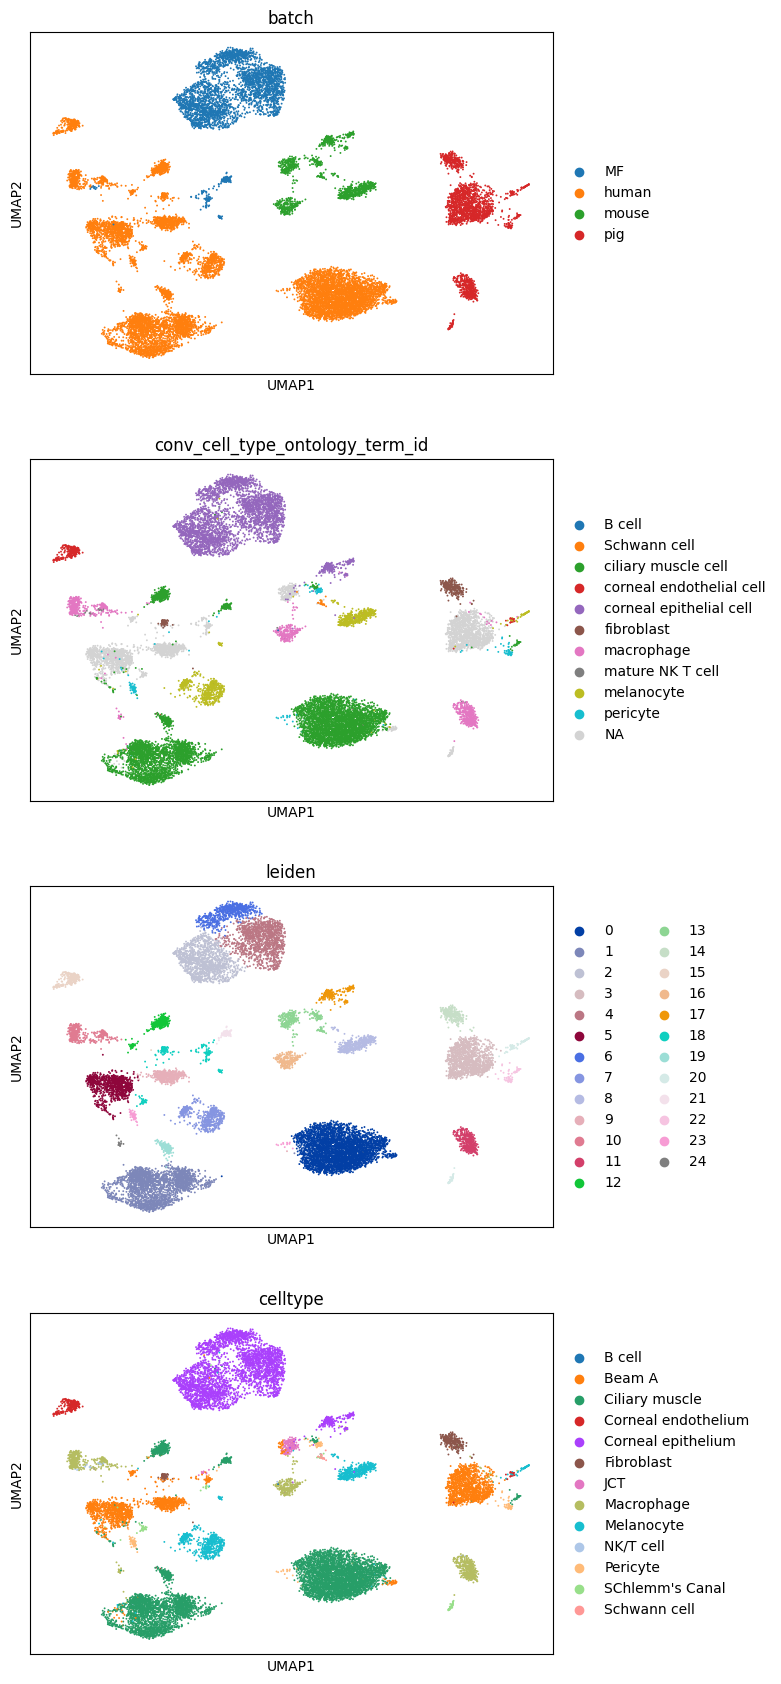

In [34]:
sc.pp.neighbors(n_adata_final, use_rep="X_pca")
sc.tl.umap(n_adata_final)
sc.tl.leiden(n_adata_final)
sc.pl.umap(n_adata_final, color=["batch", "conv_cell_type_ontology_term_id", "leiden", "celltype"], ncols=1)

## No smoothing


In [35]:
loc = n_adata_final.obs.columns[n_adata_final.obs.columns.str.startswith("CL:")]
pred = n_adata_final.obs.loc[:, loc]

In [36]:
n_adata_final.obs["pred_cell_type_ontology_term_id"] = loc[pred.values.argmax(1)].values
compute_classification(
    n_adata_final,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

{'cell_type_ontology_term_id': {'accuracy': 0.08078629529208775,
  'macro': 0.24913696907096186,
  'micro': 0.08078629529208775,
  'weighted': 0.07513417513125886}}

In [37]:
n_adata_known = n_adata_final[n_adata_final.obs["cell_type_ontology_term_id"].isin(vocab)].copy()
print(f"Kept: {n_adata_known.shape[0]} / {n_adata_final.shape[0]} cells")

print("Classification metrics for known cell types:")
compute_classification(
    n_adata_known,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

Kept: 13136 / 16228 cells
Classification metrics for known cell types:


{'cell_type_ontology_term_id': {'accuracy': 0.0998020706455542,
  'macro': 0.3170834151812242,
  'micro': 0.0998020706455542,
  'weighted': 0.09281953365027928}}

In [38]:
n_adata_final.obs["conv_pred_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["pred_cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
n_adata_final.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)

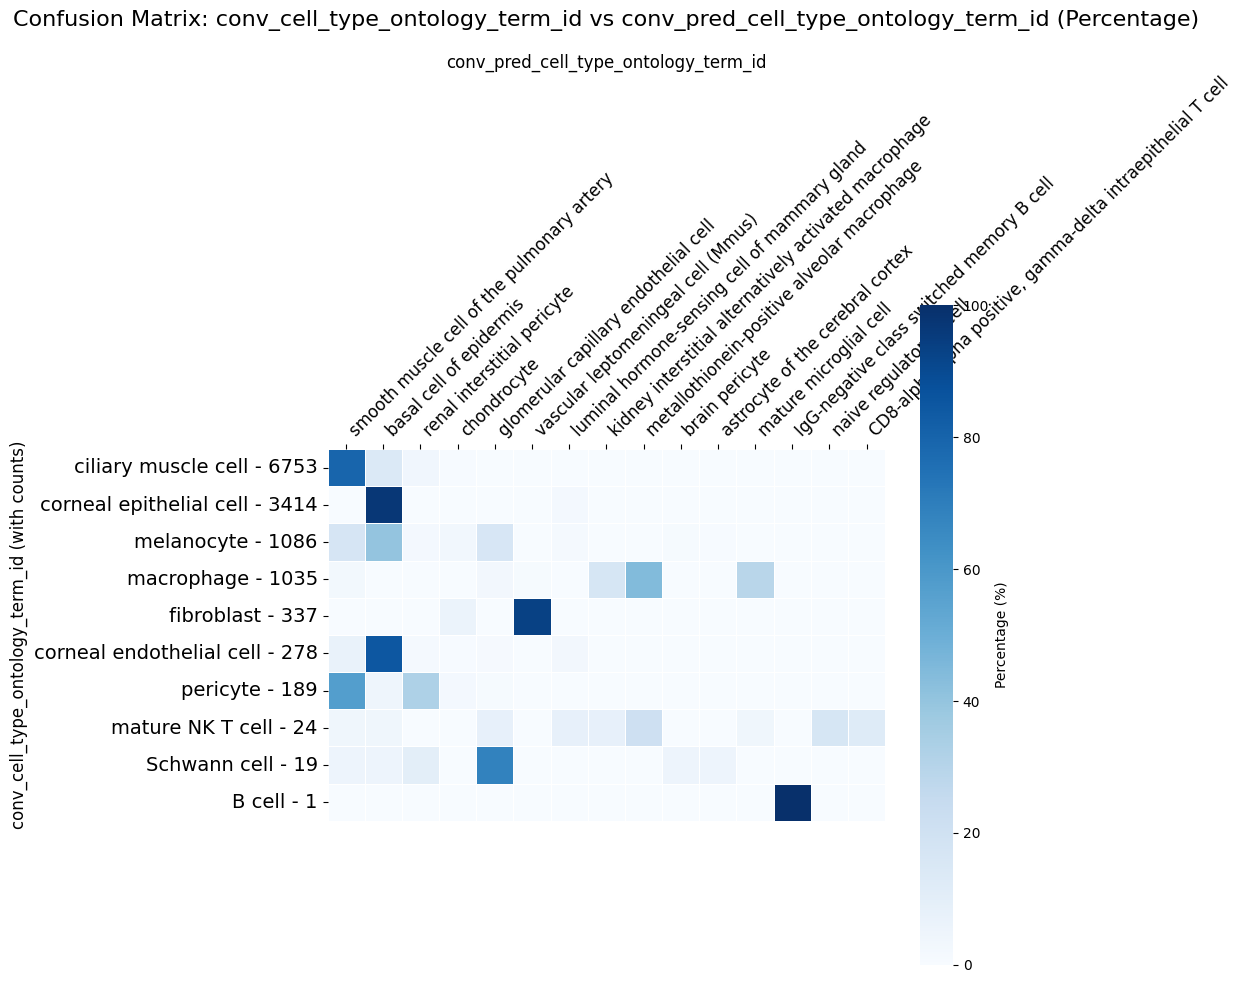

In [39]:
display_confusion_matrix(
    n_adata_final,
    "conv_pred_cell_type_ontology_term_id",
    "conv_cell_type_ontology_term_id",
)

## expert vs expert


In [40]:
print(n_adata_final.obs["pred_cell_type_ontology_term_id"].value_counts().head())

pred_cell_type_ontology_term_id
CL:0002591    5960
CL:0002187    4978
CL:0000138    1946
CL:4023056    1104
CL:4033042     469
Name: count, dtype: int64


In [41]:
print(n_adata_final.obs["celltype"].value_counts())
print(n_adata_final.obs["cell_type"].value_counts())

celltype
Ciliary muscle         6753
Corneal epithelium     3414
Beam A                 2828
Melanocyte             1086
Macrophage             1035
Fibroblast              337
Corneal endothelium     278
Pericyte                189
JCT                     170
SChlemm's Canal          94
NK/T cell                24
Schwann cell             19
B cell                    1
Name: count, dtype: int64
cell_type
Ciliary muscle         6753
Corneal epithelium     3414
Beam A                 2828
Melanocyte             1086
Macrophage             1035
Fibroblast              337
Corneal endothelium     278
Pericyte                189
JCT                     170
SChlemm's Canal          94
NK/T cell                24
Schwann cell             19
B cell                    1
Name: count, dtype: int64


In [42]:
n_adata_final.obs["pred_cell_type_ontology_term_id"] = [
    res.get(i, "unknown") for i in n_adata_final.obs["celltype"].values
]
n_adata_final.obs["cell_type_ontology_term_id"] = [
    res.get(i, "unknown") for i in n_adata_final.obs["cell_type"].values
]
compute_classification(
    n_adata_final,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

{'cell_type_ontology_term_id': {'accuracy': 1.0,
  'macro': 1.0,
  'micro': 1.0,
  'weighted': 1.0}}

In [43]:
n_adata_final.obs["conv_pred_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["pred_cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
n_adata_final.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)

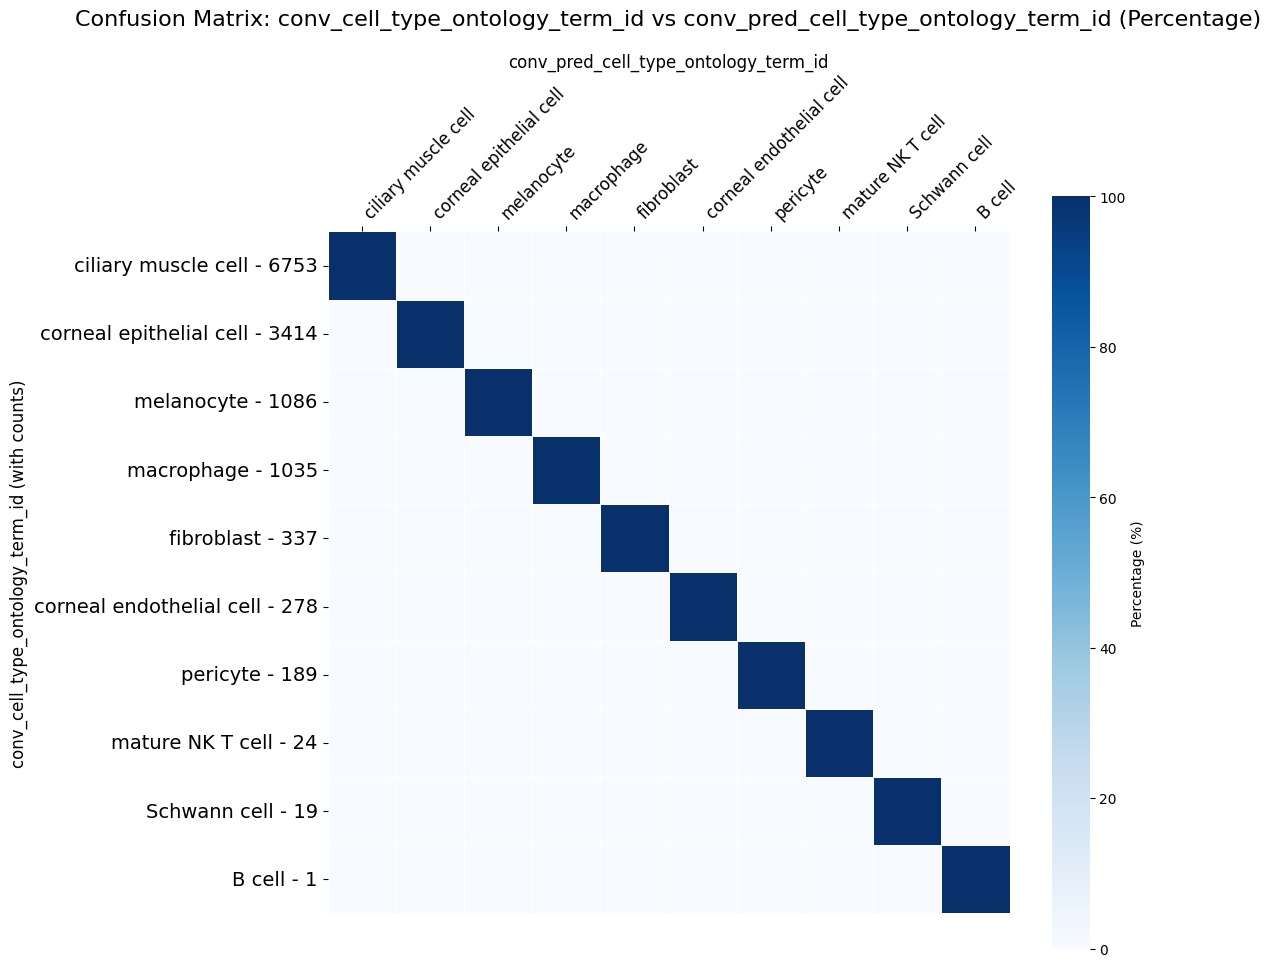

In [44]:
display_confusion_matrix(
    n_adata_final,
    "conv_pred_cell_type_ontology_term_id",
    "conv_cell_type_ontology_term_id",
)

## label smoothing


In [45]:
from scprint2.utils.graph_refinement import zero_shot_annotation_with_refinement

In [46]:
for i in range(3):
    pred.iloc[:, :] = zero_shot_annotation_with_refinement(
        pred.values, n_adata_final, return_raw=True
    ).astype(np.float32)

PairwiseArrays with keys: distances, connectivities


/local/scratch/tmp/ipykernel_1892901/349209925.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-12.382928 -14.001633 -12.918052 ... -13.767546 -12.696045 -13.812985]' has dtype incompatible with float16, please explicitly cast to a compatible dtype first.
  pred.iloc[:, :] = zero_shot_annotation_with_refinement(
/local/scratch/tmp/ipykernel_1892901/349209925.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-12.555944 -13.875466 -13.283308 ... -13.776913 -13.06816  -13.811525]' has dtype incompatible with float16, please explicitly cast to a compatible dtype first.
  pred.iloc[:, :] = zero_shot_annotation_with_refinement(
/local/scratch/tmp/ipykernel_1892901/349209925.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ -9.614688 -13.574777 -10.616158 ... -12.18602

PairwiseArrays with keys: distances, connectivities
PairwiseArrays with keys: distances, connectivities


In [47]:
n_adata_final.obs["pred_cell_type_ontology_term_id"] = loc[
    zero_shot_annotation_with_refinement(pred.values, n_adata_final)
].values
compute_classification(
    n_adata_final,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

PairwiseArrays with keys: distances, connectivities


{'cell_type_ontology_term_id': {'accuracy': 0.08294306137540054,
  'macro': 0.17166172808421942,
  'micro': 0.08294306137540054,
  'weighted': 0.07917602061980403}}

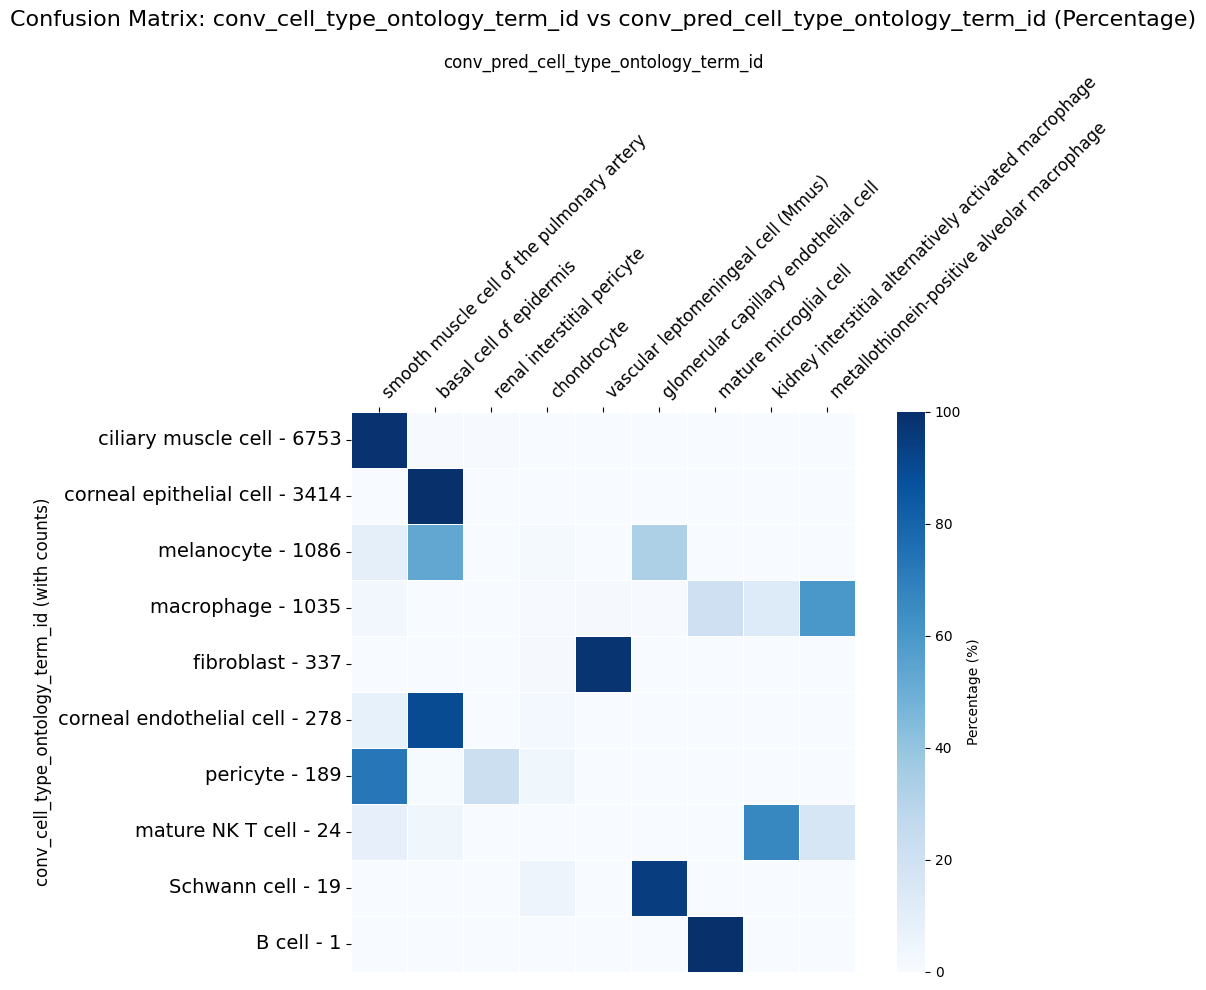

In [48]:
n_adata_final.obs["conv_pred_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["pred_cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
n_adata_final.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)

display_confusion_matrix(
    n_adata_final,
    "conv_pred_cell_type_ontology_term_id",
    "conv_cell_type_ontology_term_id",
)

## hard cluster level aggregation (using scprint embeddings)


In [49]:
sc.tl.leiden(n_adata_final, resolution=4.0)

In [50]:
for i in n_adata_final.obs["leiden"].unique():
    n_adata_final.obs.loc[
        n_adata_final.obs["leiden"] == str(i), "pred_cell_type_ontology_term_id"
    ] = loc[
        n_adata_final.obs.loc[n_adata_final.obs["leiden"] == str(i), loc]
        .values.sum(0)
        .argsort()[::-1][0]
        % len(loc)
    ]

In [51]:
sc.tl.leiden(n_adata_final, resolution=4.0)

In [52]:
compute_classification(
    n_adata_final,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

{'cell_type_ontology_term_id': {'accuracy': 0.0862706433325117,
  'macro': 0.1892187876526284,
  'micro': 0.0862706433325117,
  'weighted': 0.08224821614266645}}

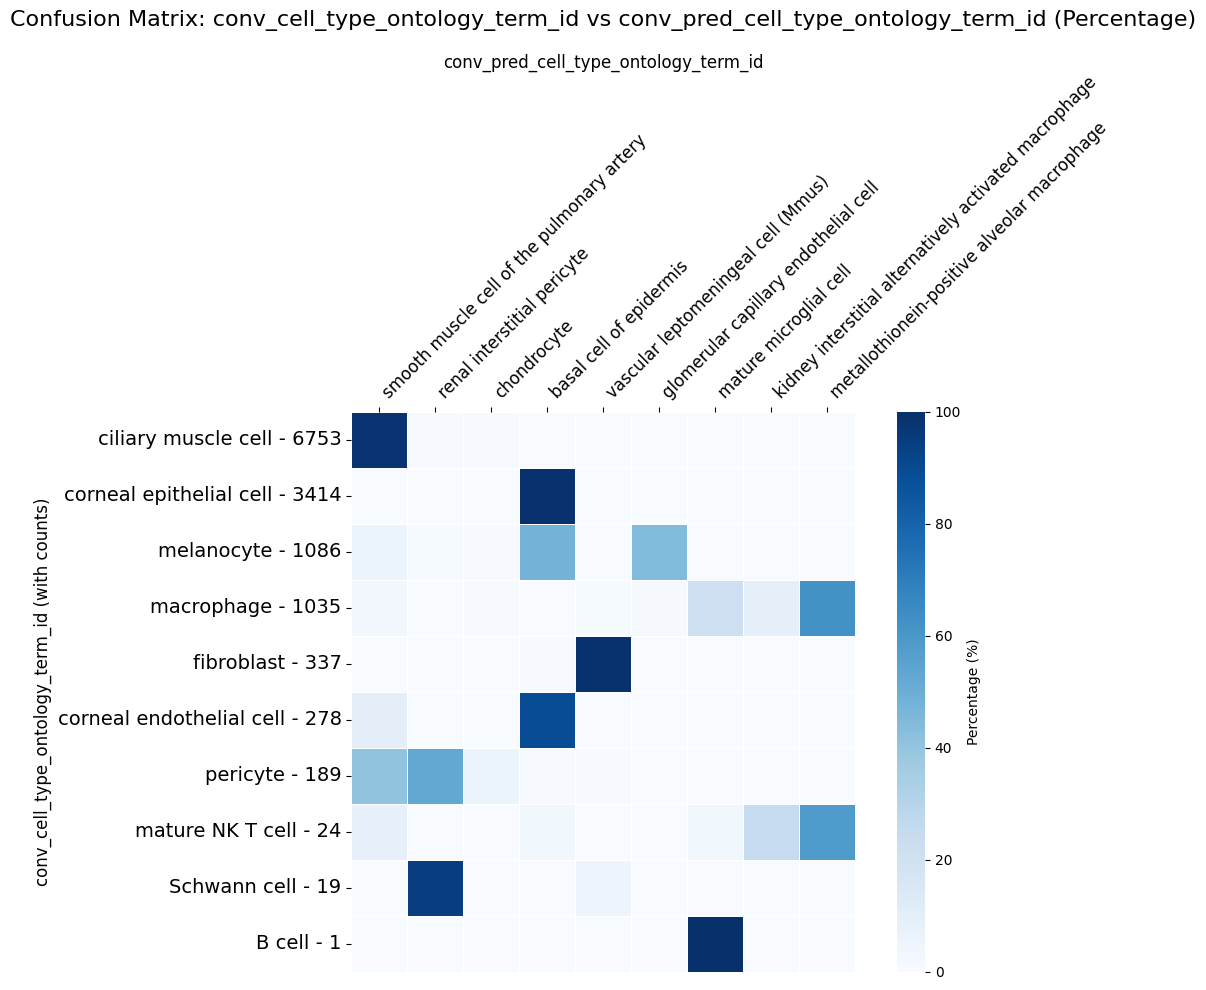

In [53]:
n_adata_final.obs["conv_pred_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["pred_cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
n_adata_final.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)

display_confusion_matrix(
    n_adata_final,
    "conv_pred_cell_type_ontology_term_id",
    "conv_cell_type_ontology_term_id",
)

## Cluster level aggregation using the dataset's computed clusters

(used for annotating cell types)


In [54]:
for i in n_adata_final.obs["cell_type_ontology_term_id"].unique():
    n_adata_final.obs.loc[
        n_adata_final.obs["cell_type_ontology_term_id"] == str(i),
        "pred_cell_type_ontology_term_id",
    ] = loc[
        n_adata_final.obs.loc[n_adata_final.obs["cell_type_ontology_term_id"] == str(i), loc]
        .values.sum(0)
        .argsort()[::-1][0]
        % len(loc)
    ]

/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [55]:
compute_classification(
    n_adata_final,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
)

{'cell_type_ontology_term_id': {'accuracy': 0.08460685235395612,
  'macro': 0.21428571428571427,
  'micro': 0.08460685235395612,
  'weighted': 0.08460685235395612}}

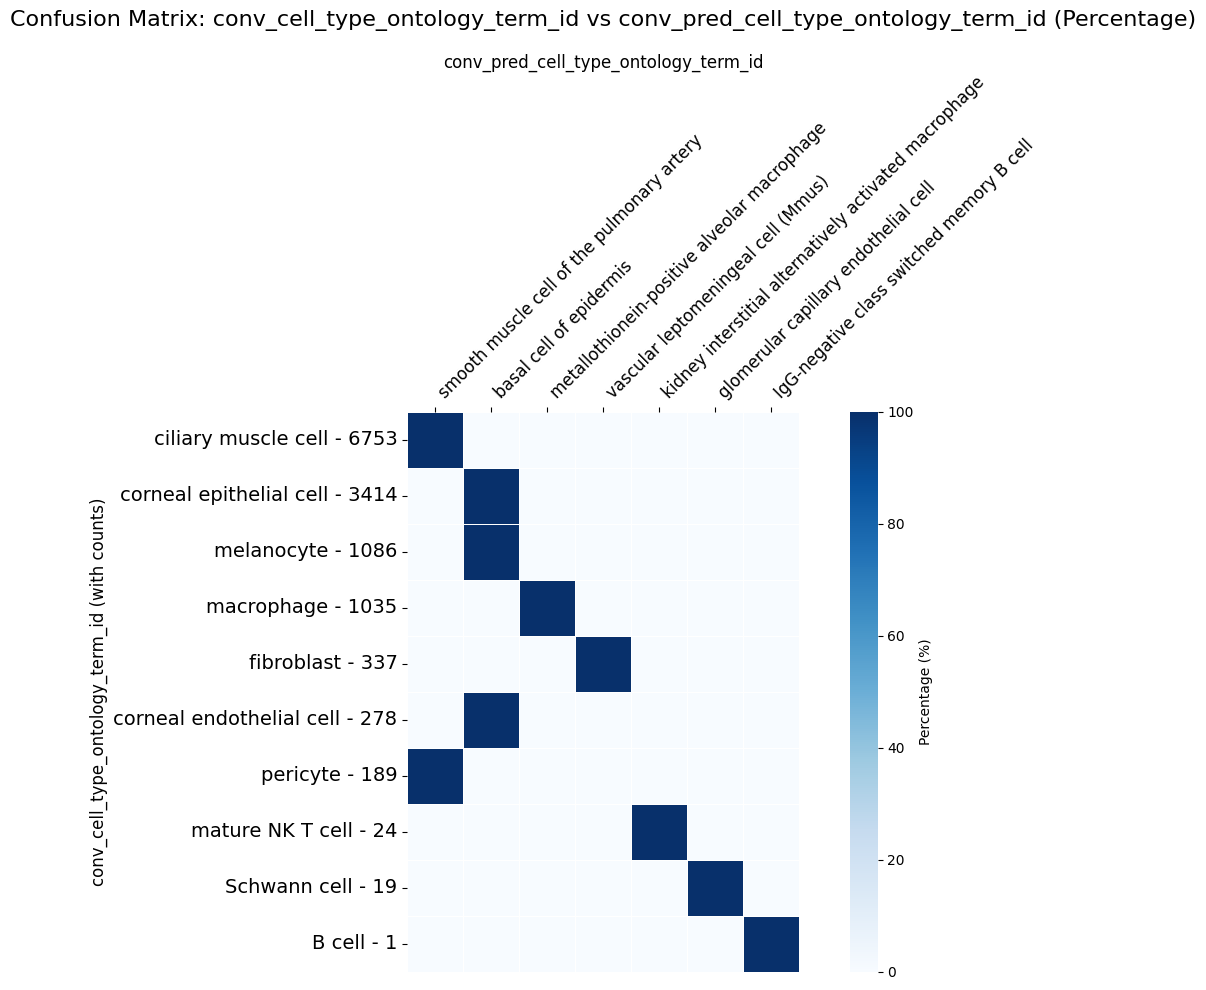

In [56]:
n_adata_final.obs["conv_pred_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["pred_cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
n_adata_final.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)

display_confusion_matrix(
    n_adata_final,
    "conv_pred_cell_type_ontology_term_id",
    "conv_cell_type_ontology_term_id",
)

## function to get coarser labels when the logits are low and similar


In [57]:
names = {
    "cell_type_ontology_term_id": "CL:",
    "disease_ontology_term_id": "MONDO:",
    "assay_ontology_term_id": "EFO:",
    "tissue_ontology_term_id": "UBERON:",  # +PATO:0000461
    "age_group": "HsapDv:",
    "self_reported_ethnicity_ontology_term_id": "HANCESTRO:",
}
CERT = 0.15
topk = 3
out = []
for label, key in names.items():
    ct = n_adata_final.obs.loc[:, n_adata_final.obs.columns.str.startswith(key)]
    res = []
    for j, m in enumerate(np.argsort(ct)[:, ::-1]):
        certainty = ct.iloc[j, m[0]]
        best = model.label_decoders[label][m[0]]
        other = []
        for i in range(1, topk):
            if (ct.iloc[j, m[i]] > certainty - CERT) or (ct.iloc[j, m[i]] > 0):
                other.extend([model.label_decoders[label][m[i]], ct.iloc[j, m[i]]])

            else:
                other.extend([None, 0])
        res.append([best] + [certainty] + other)
    out.append(
        pd.DataFrame(
            res,
            columns=["pred_" + label, "pred_" + label + "_certainty"]
            + sum(
                [
                    [f"pred_{label}_choice_{i}", f"pred_{label}_choice_{i}_certainty"]
                    for i in range(2, topk + 1)
                ],
                [],
            ),
            index=n_adata_final.obs_names,
        )
    )
out = pd.concat(out, axis=1)

decoder = {i: {k: v for k, v in model.label_decoders[i].items()} for i in names.keys()}
hier = {
    i: {
        decoder[i][k]: [decoder[i][u] for u in v]
        for k, v in model.labels_hierarchy[i].items()
    }
    for i in names.keys()
}

## looking at parental relationships
rev_hier = {i: {} for i in names.keys()}
for i, hier in rev_hier.items():
    for k, v in hier.items():
        for u in v:
            if u in rev_hier:
                rev_hier[i][u].append(k)
            else:
                rev_hier[i][u] = [k]

## second step, also setting to unknown if nothing can be resolved


In [58]:
CERT2 = 0.4
new = {i: [] for i in names.keys()}
for idx, row in out.iterrows():
    for i in names.keys():
        # we only have the first one
        if row["pred_" + i + "_choice_2"] is None:
            new[i].append(row["pred_" + i])
            continue
        # we have the third one and want it to at least agree on the most common label
        # if row["pred_" + i + "_choice_3"] is not None:
        #    if (
        #        len(
        #            set(rev_hier[i].get(row["pred_" + i], []))
        #            & set(rev_hier[i].get(row["pred_" + i + "_choice_2"], []))
        #            & set(rev_hier[i].get(row["pred_" + i + "_choice_3"], []))
        #            - set(["CL:0000000"])
        #        )
        #        == 0
        #    ):
        #        new[i].append("unknown")
        #        continue
        # if we have the second one and the third one agrees a bit
        res = set(rev_hier[i].get(row["pred_" + i], [])) & set(
            rev_hier[i].get(row["pred_" + i + "_choice_2"], [])
        ) - set(["CL:0000000"])
        # if the certainty is overall low, we say unknown
        if row["pred_" + i + "_certainty"] < 0:
            new[i].append("unknown")
        # if only one agrees, we take it
        elif len(res) == 0:
            new[i].append(row["pred_" + i])
        # if more than one agrees and we are much more confident for the second than the first, then we select the first
        elif len(res) == 1:
            if (
                row["pred_" + i + "_certainty"]
                > row["pred_" + i + "_choice_2_certainty"] + CERT2
            ):
                new[i].append(row["pred_" + i])
            # else we set it to the parental
            else:
                new[i].append(list(res)[0])
        # if more agrees, we take the most specific, meaning the one with the most parental elements
        else:
            sel = ""
            top = 0
            # this is a debugger line
            import pdb

            pdb.set_trace()
            for elem in res:
                if len(rev_hier[i][elem]) > top:
                    top = len(rev_hier[i][elem])
                    sel = i
            new[i].append(sel)

for i in names.keys():
    n_adata_final.obs["pred_" + i] = new[i]

In [59]:
compute_classification(
    n_adata_final,
    ["cell_type_ontology_term_id"],
    label_decoders=model.label_decoders,
    labels_hierarchy=model.labels_hierarchy,
    use_unknown=False,
)

{'cell_type_ontology_term_id': {'accuracy': 0.0875345886481744,
  'macro': 0.25072840774347366,
  'micro': 0.0875345886481744,
  'weighted': 0.08187914532649236}}

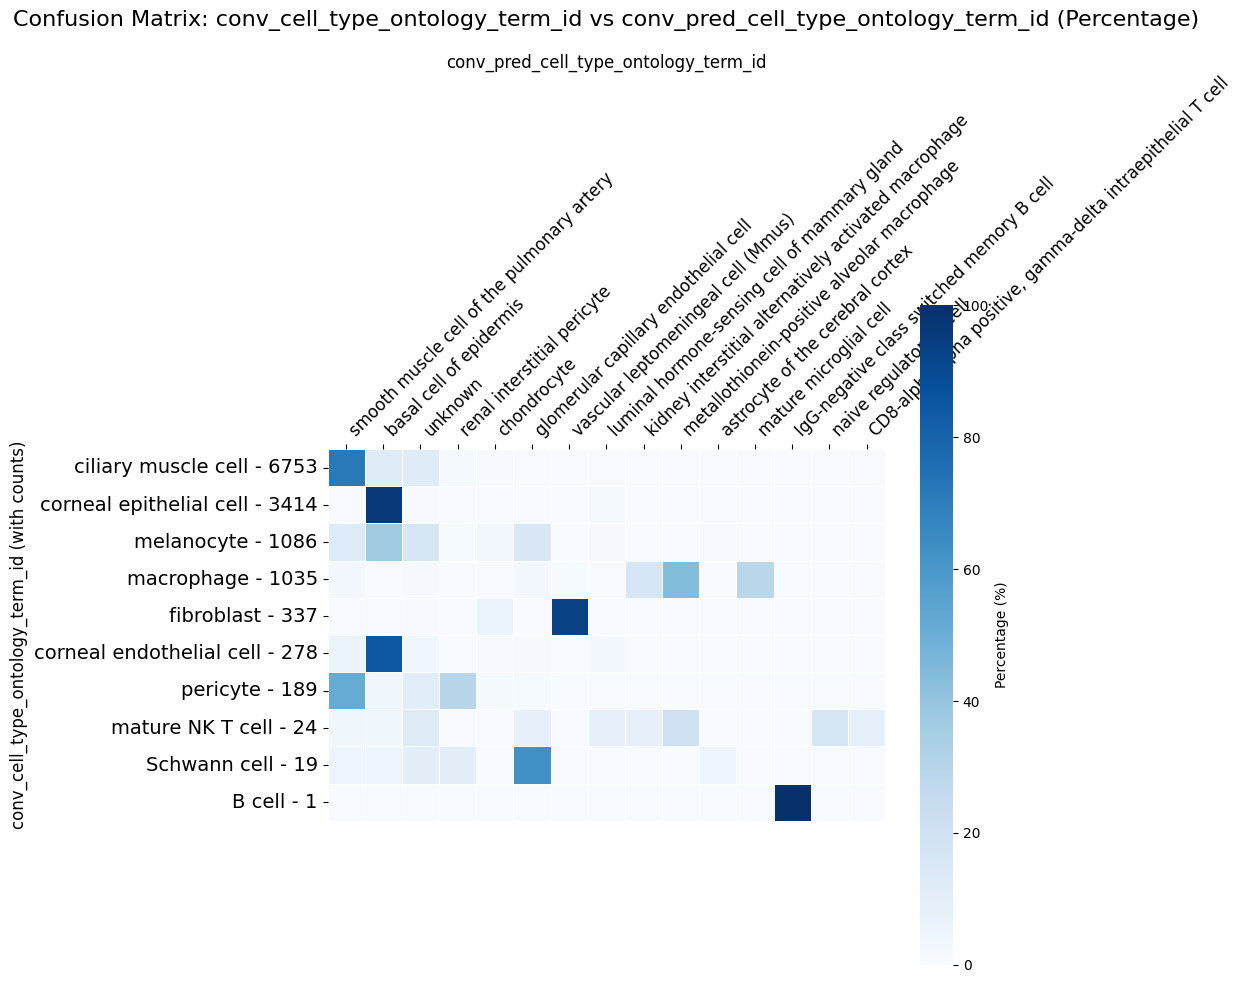

In [60]:
n_adata_final.obs["conv_pred_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["pred_cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
n_adata_final.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)

display_confusion_matrix(
    n_adata_final,
    "conv_pred_cell_type_ontology_term_id",
    "conv_cell_type_ontology_term_id",
)

# Looking at embedding quality


In [61]:
import matplotlib.pyplot as plt

sc.settings.set_figure_params(
    dpi=150,
    fontsize=10,
    frameon=True,
    vector_friendly=True,
)

plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.transparent"] = False

In [62]:
n_adata_final.obs["conv_pred_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["pred_cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)
n_adata_final.obs["conv_cell_type_ontology_term_id"] = translate(
    n_adata_final.obs["cell_type_ontology_term_id"], "cell_type_ontology_term_id"
)

... storing 'cell_type_ontology_term_id' as categorical
... storing 'conv_cell_type_ontology_term_id' as categorical
... storing 'pred_cell_type_ontology_term_id' as categorical
... storing 'conv_pred_cell_type_ontology_term_id' as categorical
... storing 'pred_disease_ontology_term_id' as categorical
... storing 'pred_assay_ontology_term_id' as categorical
... storing 'pred_tissue_ontology_term_id' as categorical
... storing 'pred_age_group' as categorical
... storing 'pred_self_reported_ethnicity_ontology_term_id' as categorical


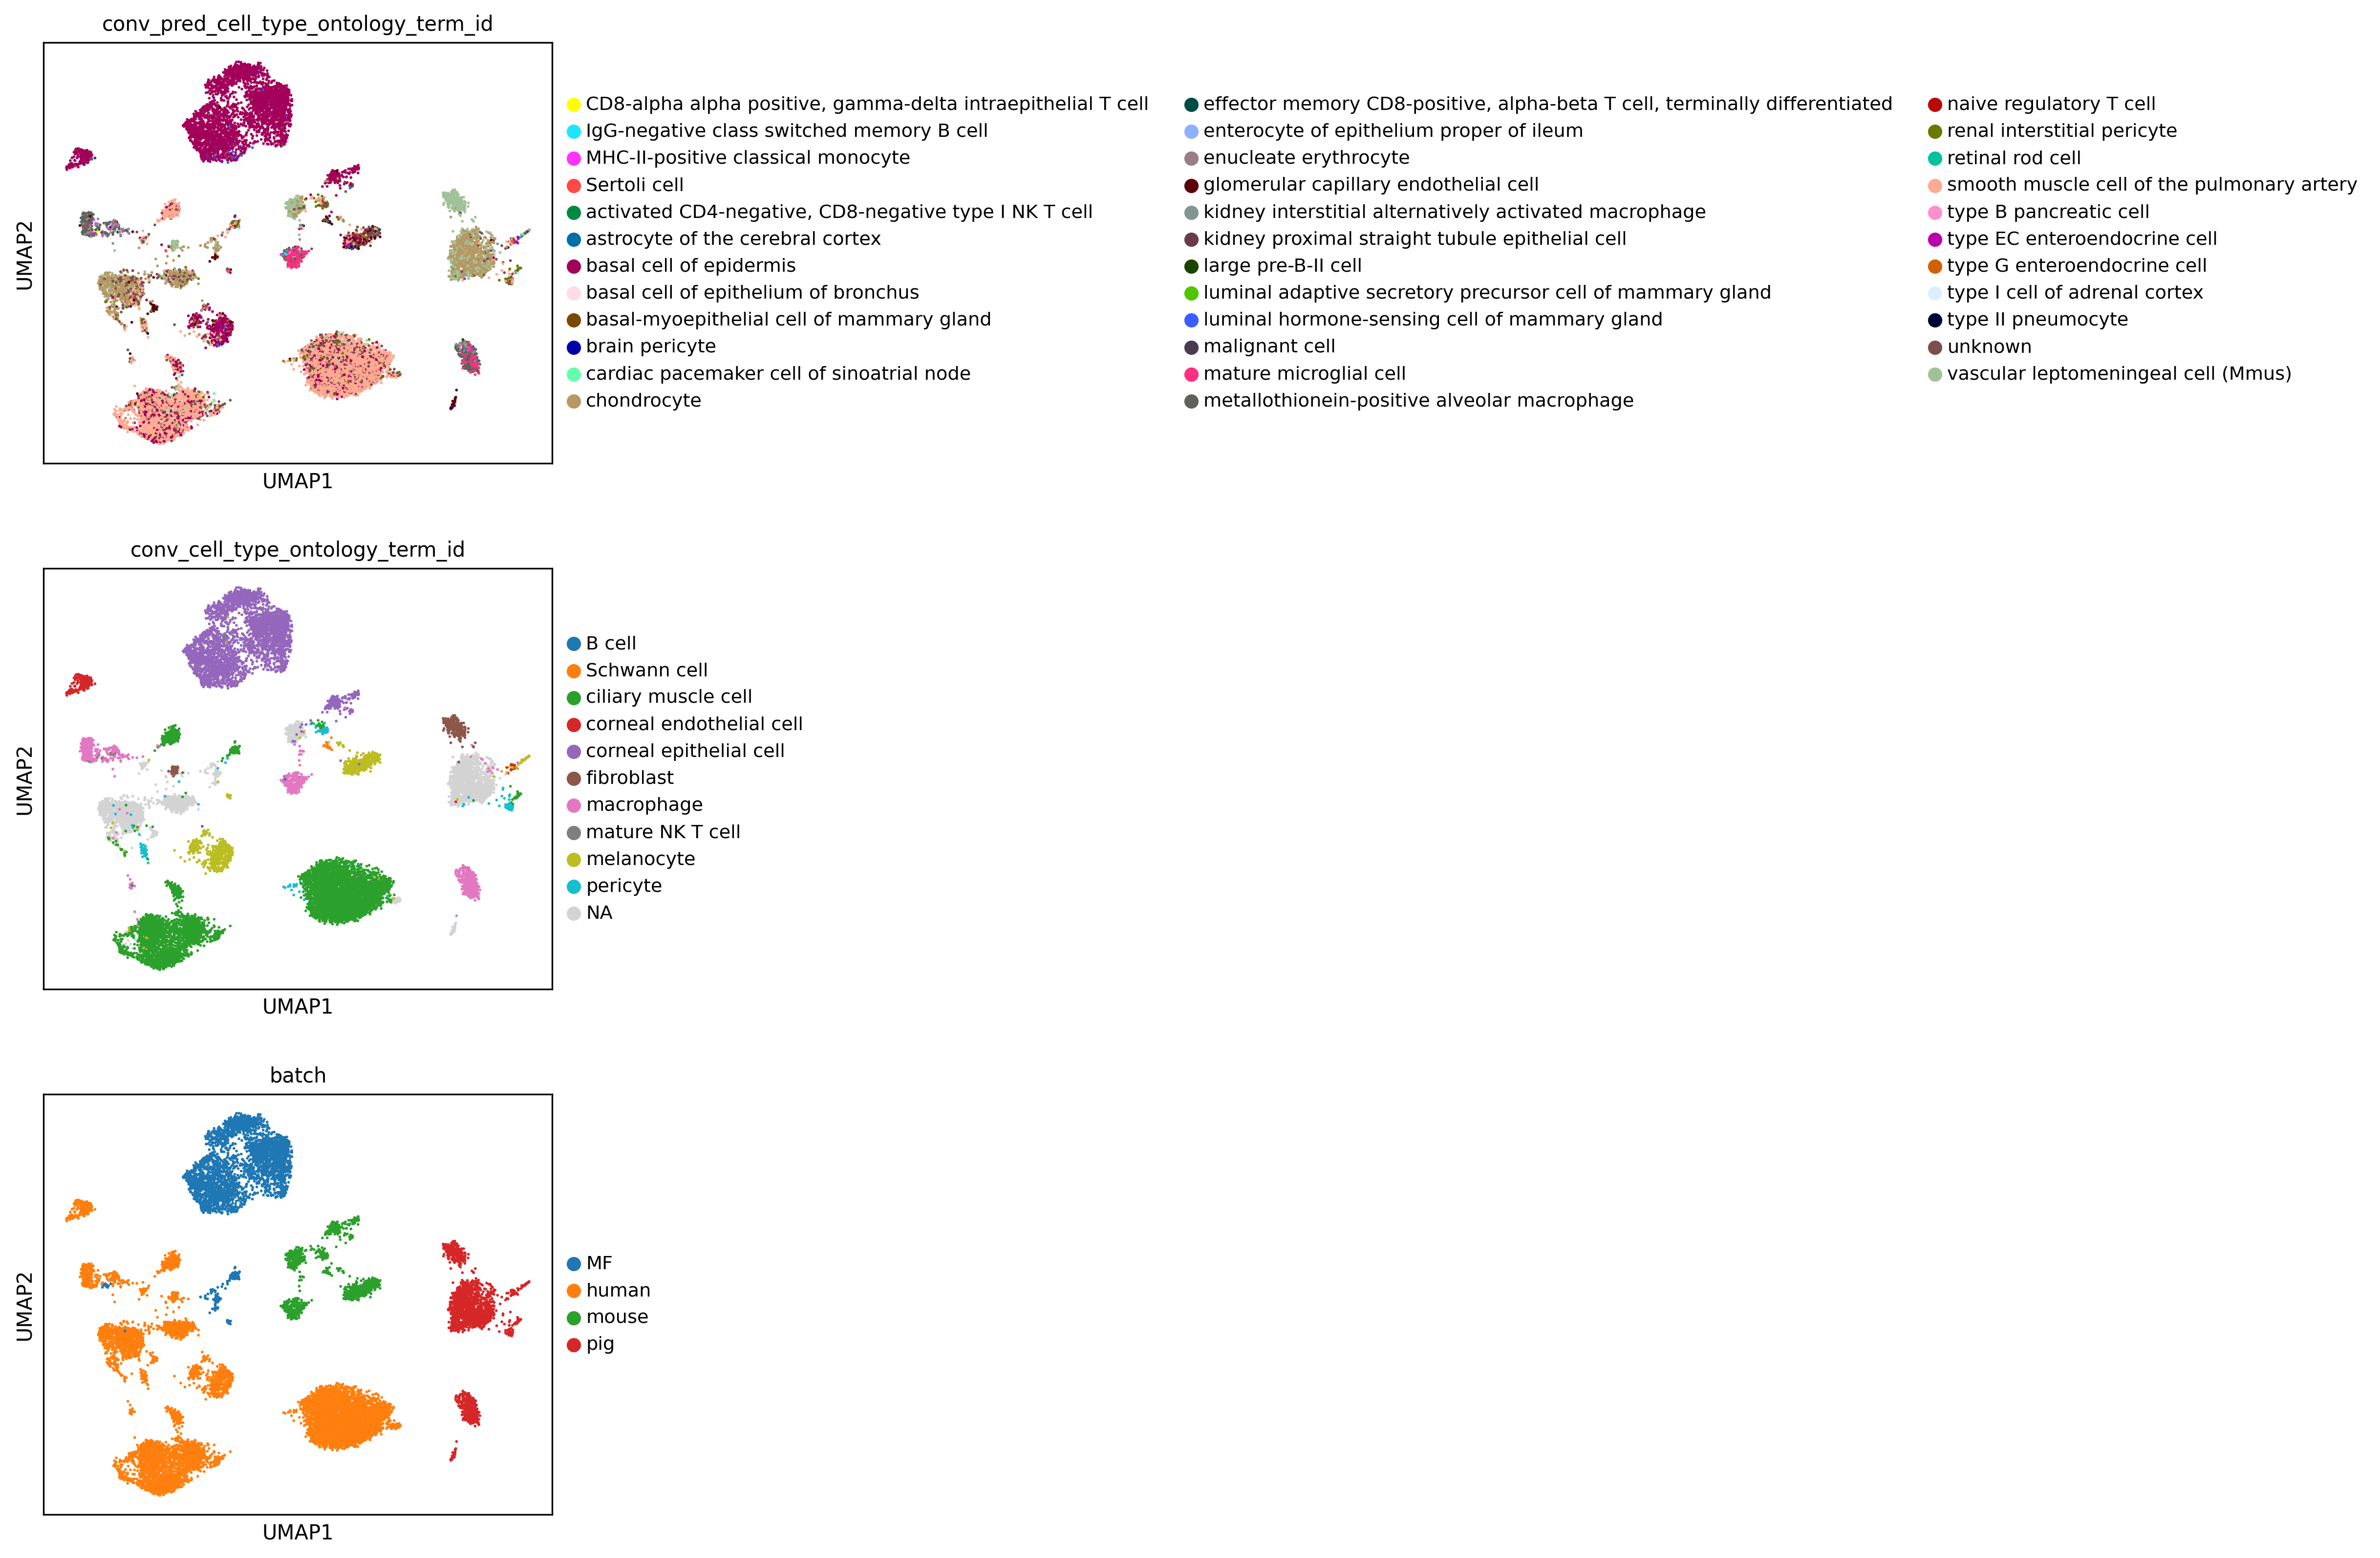

In [63]:
sc.pp.neighbors(n_adata_final, use_rep="X_pca")
sc.tl.umap(n_adata_final)
sc.pl.umap(
    n_adata_final,
    color=[
        "conv_pred_cell_type_ontology_term_id",
        "conv_cell_type_ontology_term_id",
        "batch",
    ],
    ncols=1,
)

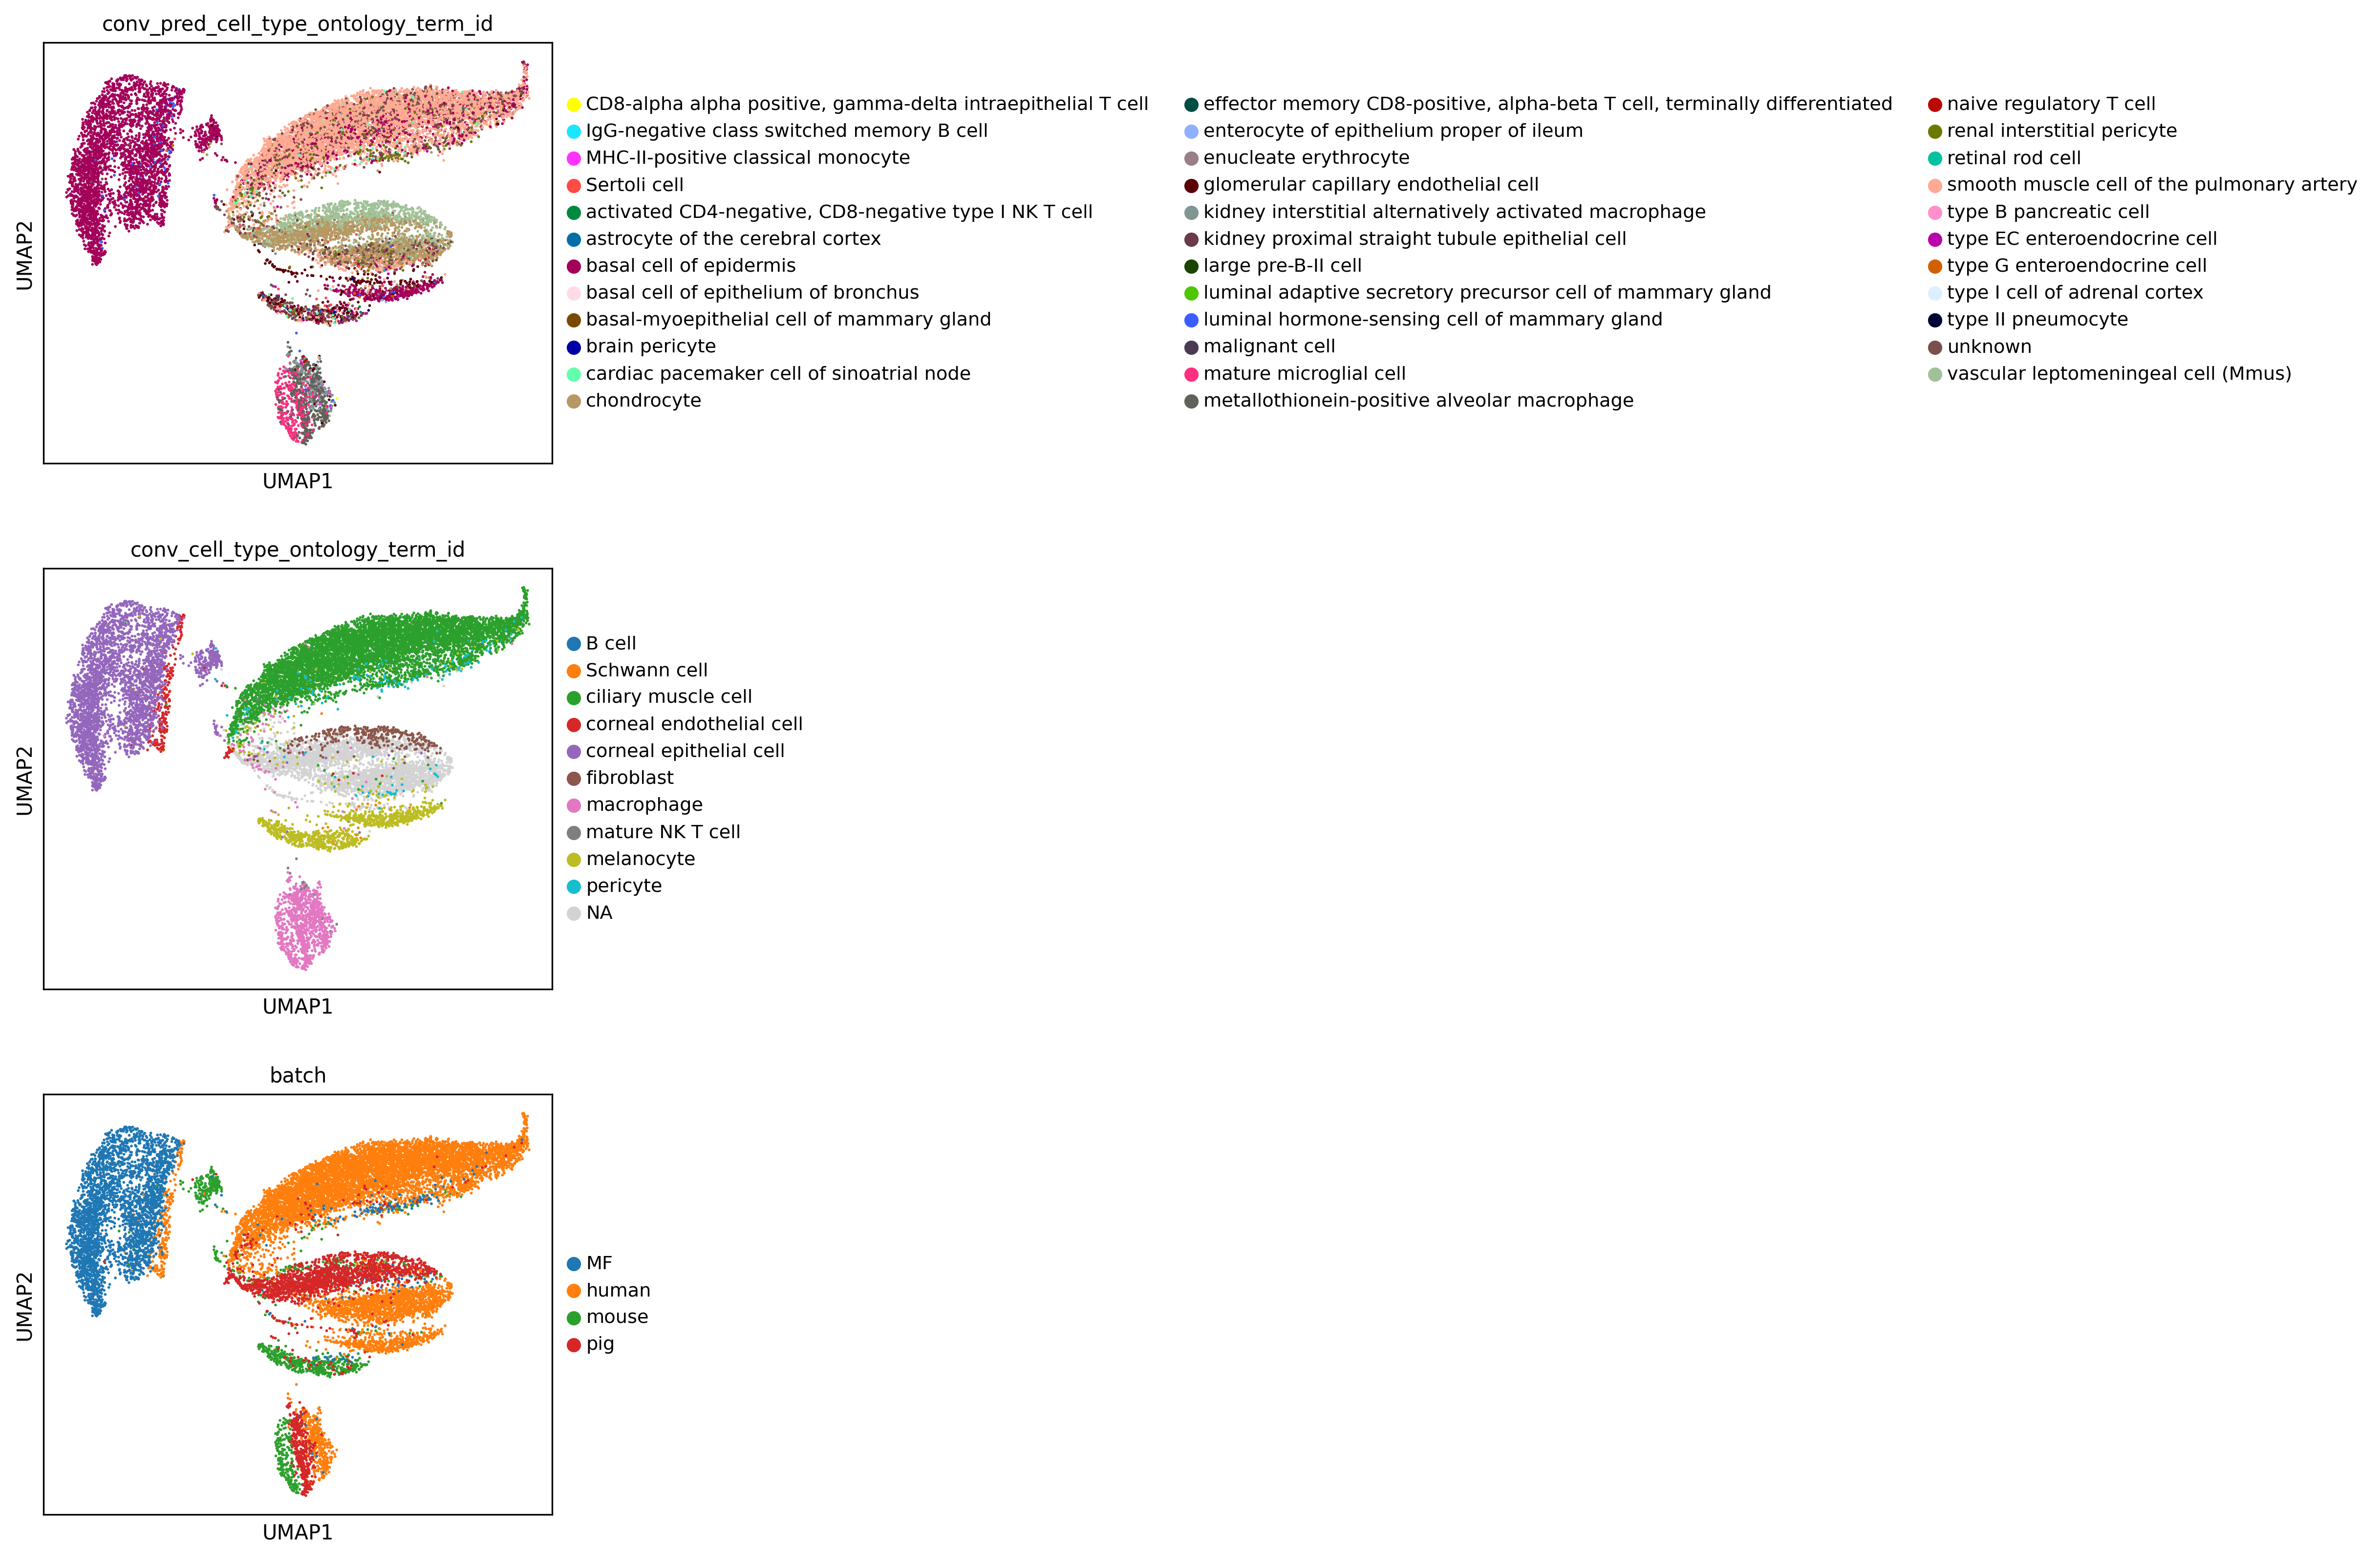

In [64]:
sc.pp.neighbors(n_adata_final, use_rep="scprint_emb_cell_type_ontology_term_id")
sc.tl.umap(n_adata_final)
sc.pl.umap(
    n_adata_final,
    color=[
        "conv_pred_cell_type_ontology_term_id",
        "conv_cell_type_ontology_term_id",
        "batch",
    ],
    ncols=1,
)

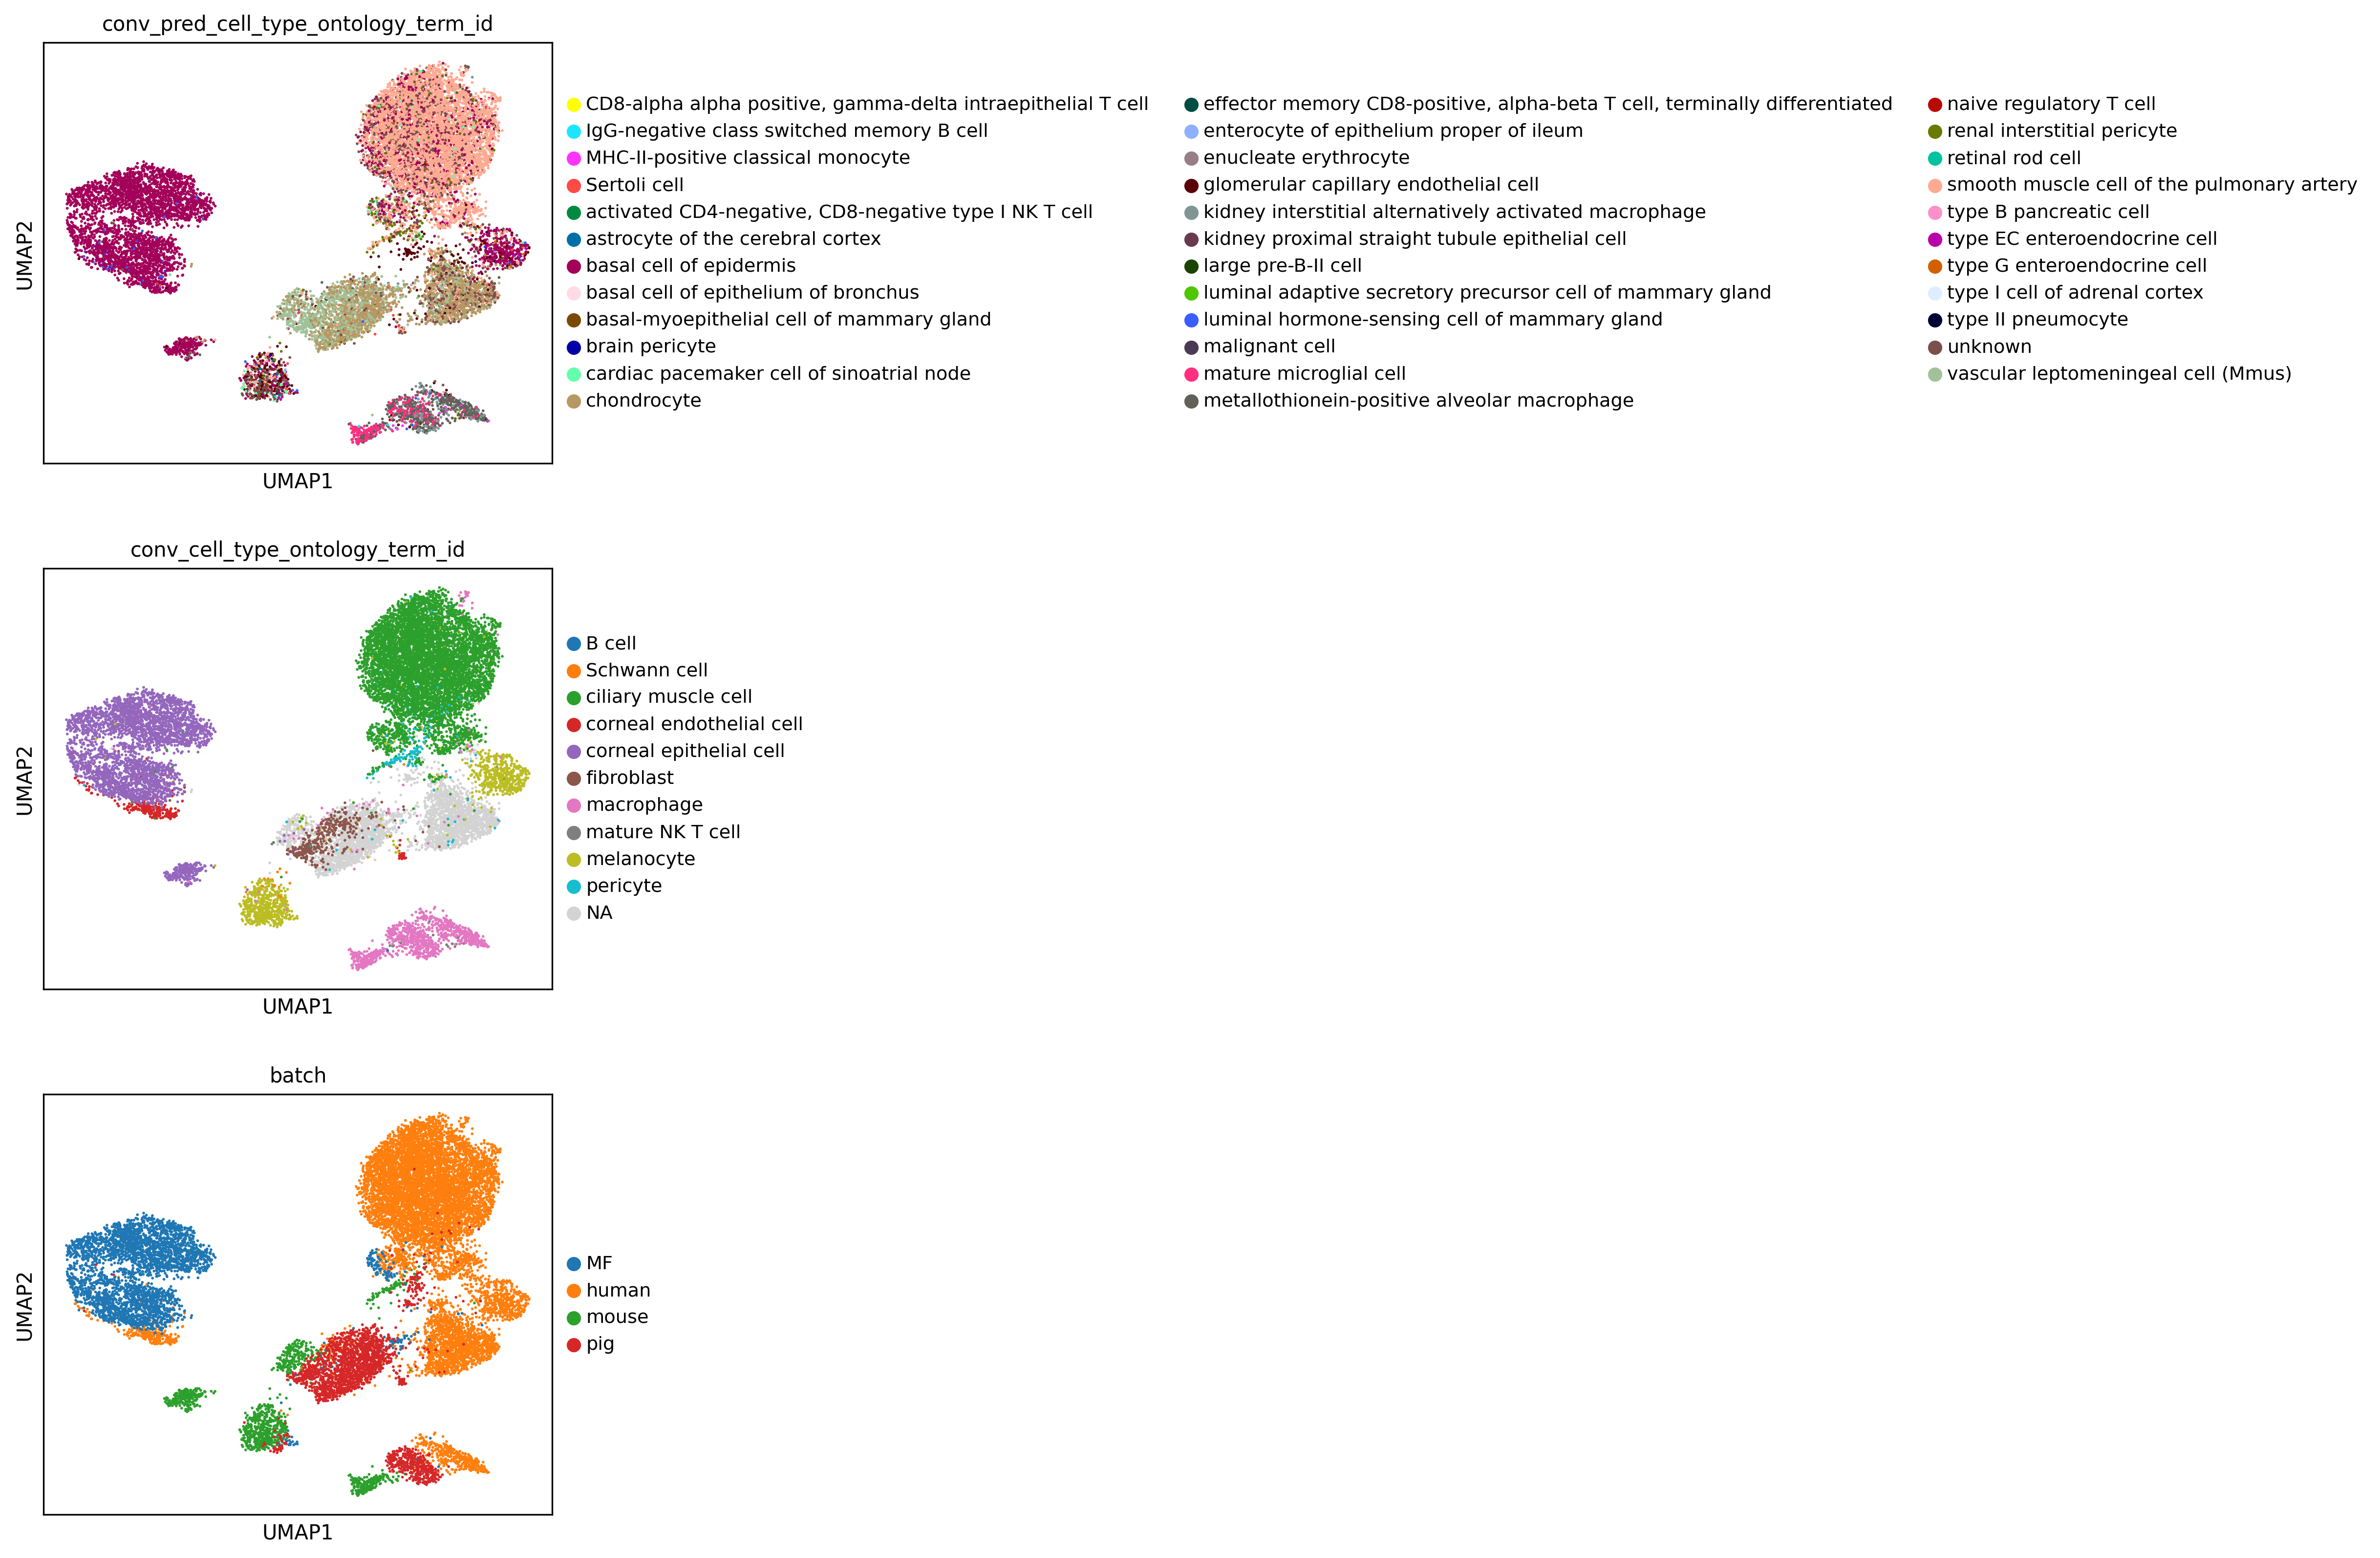

In [65]:
# as above
sc.pp.neighbors(n_adata_final, use_rep="scprint_emb")
sc.tl.umap(n_adata_final)
sc.pl.umap(
    n_adata_final,
    color=[
        "conv_pred_cell_type_ontology_term_id",
        "conv_cell_type_ontology_term_id",
        "batch",
    ],
    ncols=1,
)

##  scIB on batch (species)

In [76]:
n_adata_final

AnnData object with n_obs × n_vars = 16228 × 57066
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'NAME', 'cell_type', 'batch', 'n_genes', 'celltype', 'organism_ontology_term_id', 'nnz', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'batches', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'CL:0000001', 'CL:0000003', 'CL:0000019', 'CL:0000023', 'CL:0000024', 'CL:0000032', 'CL:0000047', 'CL:0000049', 'CL:0000050', 'CL:0000051', 'CL:0000062', 'CL:0000091', 'CL:0000092', 'CL:0000097', 'CL:0000114', 'CL:0000119', 'CL:0000121', 'CL:0000122', 'CL:0000128', 'CL:0000131', 'CL:0000132', 'CL:0000133', 'CL:0000138', 'CL:0000155', 'CL:0000158', 'CL:0000162', 'CL:0000169', 'CL:0000171', 'CL:0000173', 'CL:

In [ ]:
""" # required for other approahces
sc.pp.normalize_total(n_adata, target_sum=1e4)
sc.pp.log1p(n_adata)
sc.pp.pca(n_adata)
sc.pp.neighbors(n_adata, use_rep="X_pca") """

In [77]:
n_adata_final.obsm["random"] = np.random.rand(*n_adata_final.obsm["X_pca"].shape)

In [83]:
n_adata_final.obs["batch"].value_counts()

batch
human    9469
MF       3398
pig      2117
mouse    1244
Name: count, dtype: int64

In [ ]:
bm = Benchmarker(
    n_adata_final,
    batch_key="batch",  # batch, tech, assay_ontology_term_id, donor_id
    label_key="celltype",  # celltype
    embedding_obsm_keys=[
        "scprint_emb",
        "X_pca",
        "random",
        "scprint_emb_cell_type_ontology_term_id",
    ],
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    n_jobs=11,
)
bm.benchmark()
bm.get_results(min_max_scale=False)

/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings:   0%|          | 0/4 [00:00<?, ?it/s]Mon Aug 10 14:38:20 2026 INFO isolated labels: no more than 1 batches per label


INFO     B cell consists of a single batch or is too small. Skip.                                                  


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Seri

INFO     Schwann cell consists of a single batch or is too small. Skip.                                            


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_graph_connectivity.py:30: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings:  25%|██▌       | 1/4 [01:21<04:04, 81.54s/it]Mon Aug 10 14:39:42 2026 INFO isolated labels: no more than 1 batches per label


...

INFO     B cell consists of a single batch or is too small. Skip.                                                  


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Seri

INFO     Schwann cell consists of a single batch or is too small. Skip.                                            


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_graph_connectivity.py:30: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
Embeddings: 100%|██████████| 4/4 [03:39<00:00, 54.92s/it]


,Isolated labels,KMeans NMI,KMeans ARI,Silhouette label,cLISI,Silhouette batch,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total
Embedding,,,,,,,,,,,,,
scprint_emb,0.549904,0.589076,0.3531,0.562929,1.0,0.798639,0.0,0.211794,0.823308,0,0.366748,0.611002,0.5133
X_pca,0.627236,0.50831,0.32719,0.486706,1.0,0.742288,0.0,0.184733,0.817355,0.0,0.348875,0.589888,0.493483
random,0.488031,0.002406,0.000066,0.475716,0.813895,0.98222,0.428121,0.43155,0.249982,0.99937,0.618249,0.356023,0.460913
scprint_emb_cell_type_ontology_term_id,0.549734,0.510118,0.30861,0.535832,1.0,0.821281,0.0,0.292497,0.848346,0.205557,0.433536,0.580859,0.52193
Metric Type,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Batch correction,Batch correction,Batch correction,Batch correction,Batch correction,Aggregate score,Aggregate score,Aggregate score


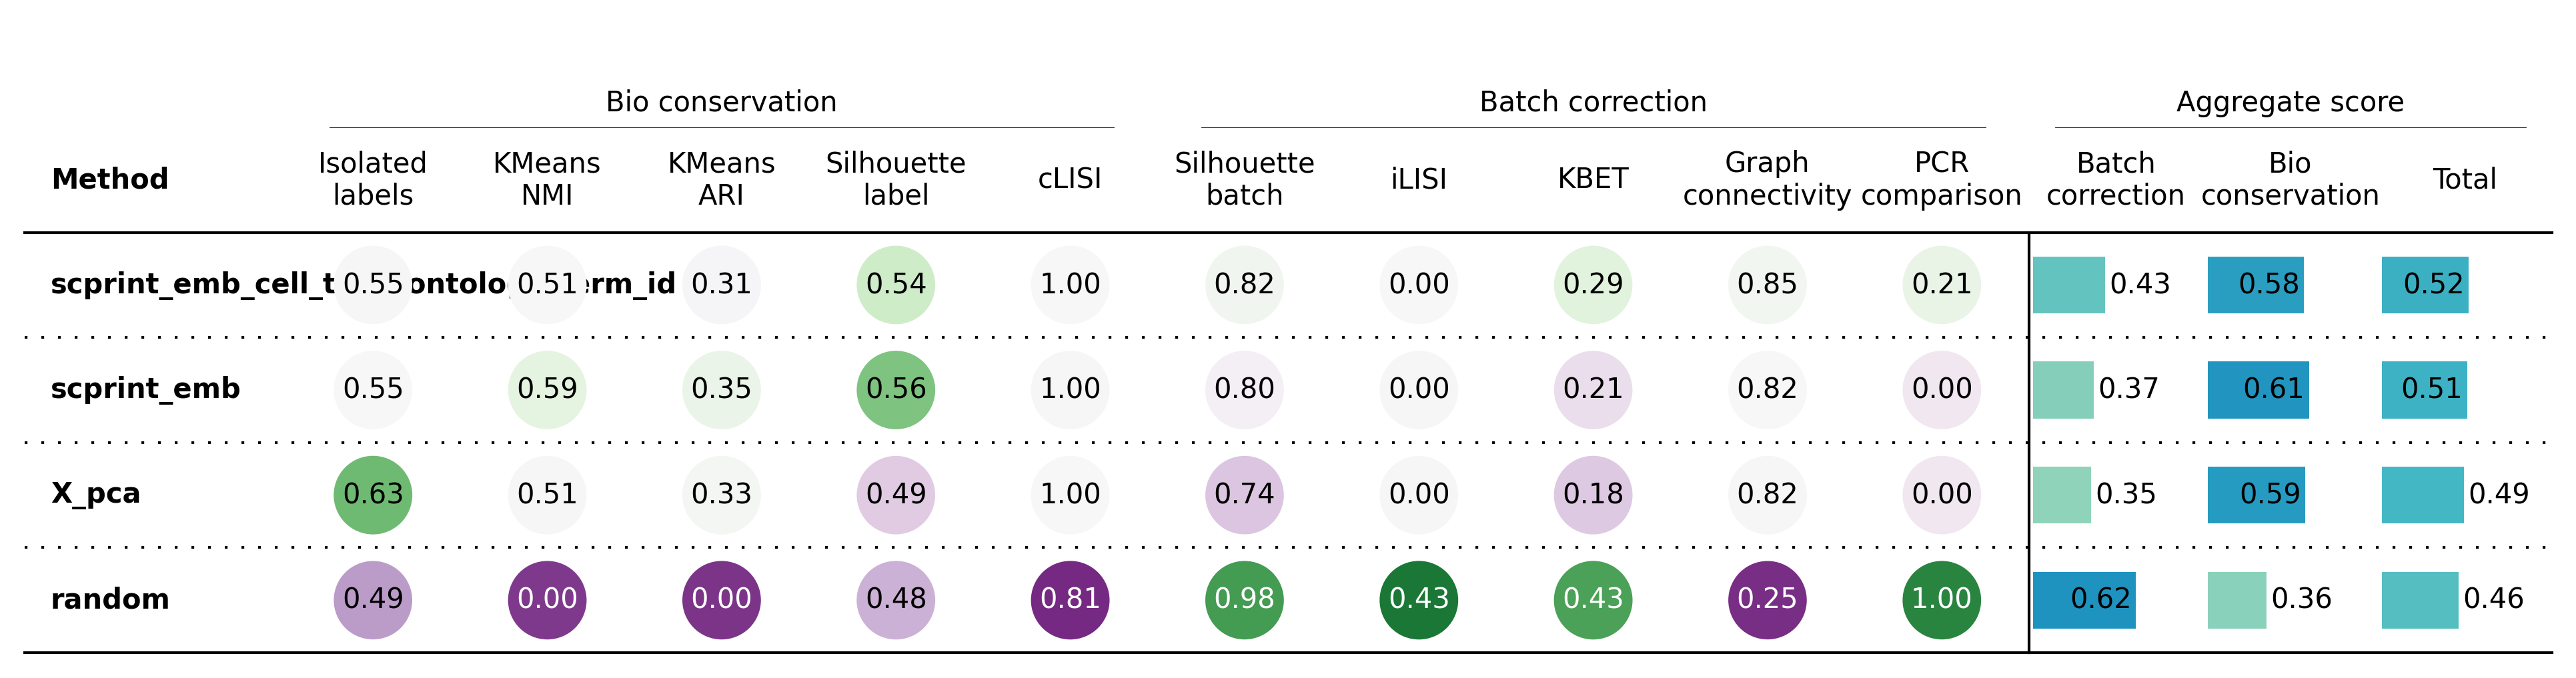

In [85]:
# cell_type embedding latest
bm.plot_results_table(min_max_scale=False)

In [86]:
# most expr and w..
bm = Benchmarker(
    n_adata_final,
    batch_key="batch",  # batch, tech, assay_ontology_term_id, donor_id
    label_key="cell_type_ontology_term_id",  # celltype
    embedding_obsm_keys=[
        "scprint_emb",
        "X_pca",
        "random",
        "scprint_emb_cell_type_ontology_term_id",
    ],
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    n_jobs=10,
)
bm.benchmark()
bm.get_results(min_max_scale=False)

/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings:   0%|          | 0/4 [00:00<?, ?it/s]Mon Aug 10 14:42:31 2026 INFO isolated labels: no more than 1 batches per label
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_si

INFO     CL:0000236 consists of a single batch or is too small. Skip.                                              


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)


INFO     CL:0002573 consists of a single batch or is too small. Skip.                                              


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Seri

...

INFO     CL:0000236 consists of a single batch or is too small. Skip.                                              


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)


INFO     CL:0002573 consists of a single batch or is too small. Skip.                                              


/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_kbet.py:181: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  comp_size = pd.value_counts(labs)
/pasteur/appa/homes/jkalfon/scPRINT/.venv/lib/python3.11/site-packages/scib_metrics/_graph_connectivity.py:30: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version

,Isolated labels,KMeans NMI,KMeans ARI,Silhouette label,cLISI,Silhouette batch,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total
Embedding,,,,,,,,,,,,,
scprint_emb,0.549904,0.589076,0.3531,0.562929,1.0,0.798639,0.0,0.211762,0.823308,0,0.366742,0.611002,0.513298
X_pca,0.627236,0.50831,0.32719,0.486706,1.0,0.742288,0.0,0.184733,0.817355,0.0,0.348875,0.589888,0.493483
random,0.488031,0.002406,0.000066,0.475716,0.813895,0.98222,0.428121,0.43155,0.249982,0.99937,0.618249,0.356023,0.460913
scprint_emb_cell_type_ontology_term_id,0.549734,0.510118,0.30861,0.535832,1.0,0.821281,0.0,0.292529,0.848346,0.205557,0.433543,0.580859,0.521932
Metric Type,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Batch correction,Batch correction,Batch correction,Batch correction,Batch correction,Aggregate score,Aggregate score,Aggregate score


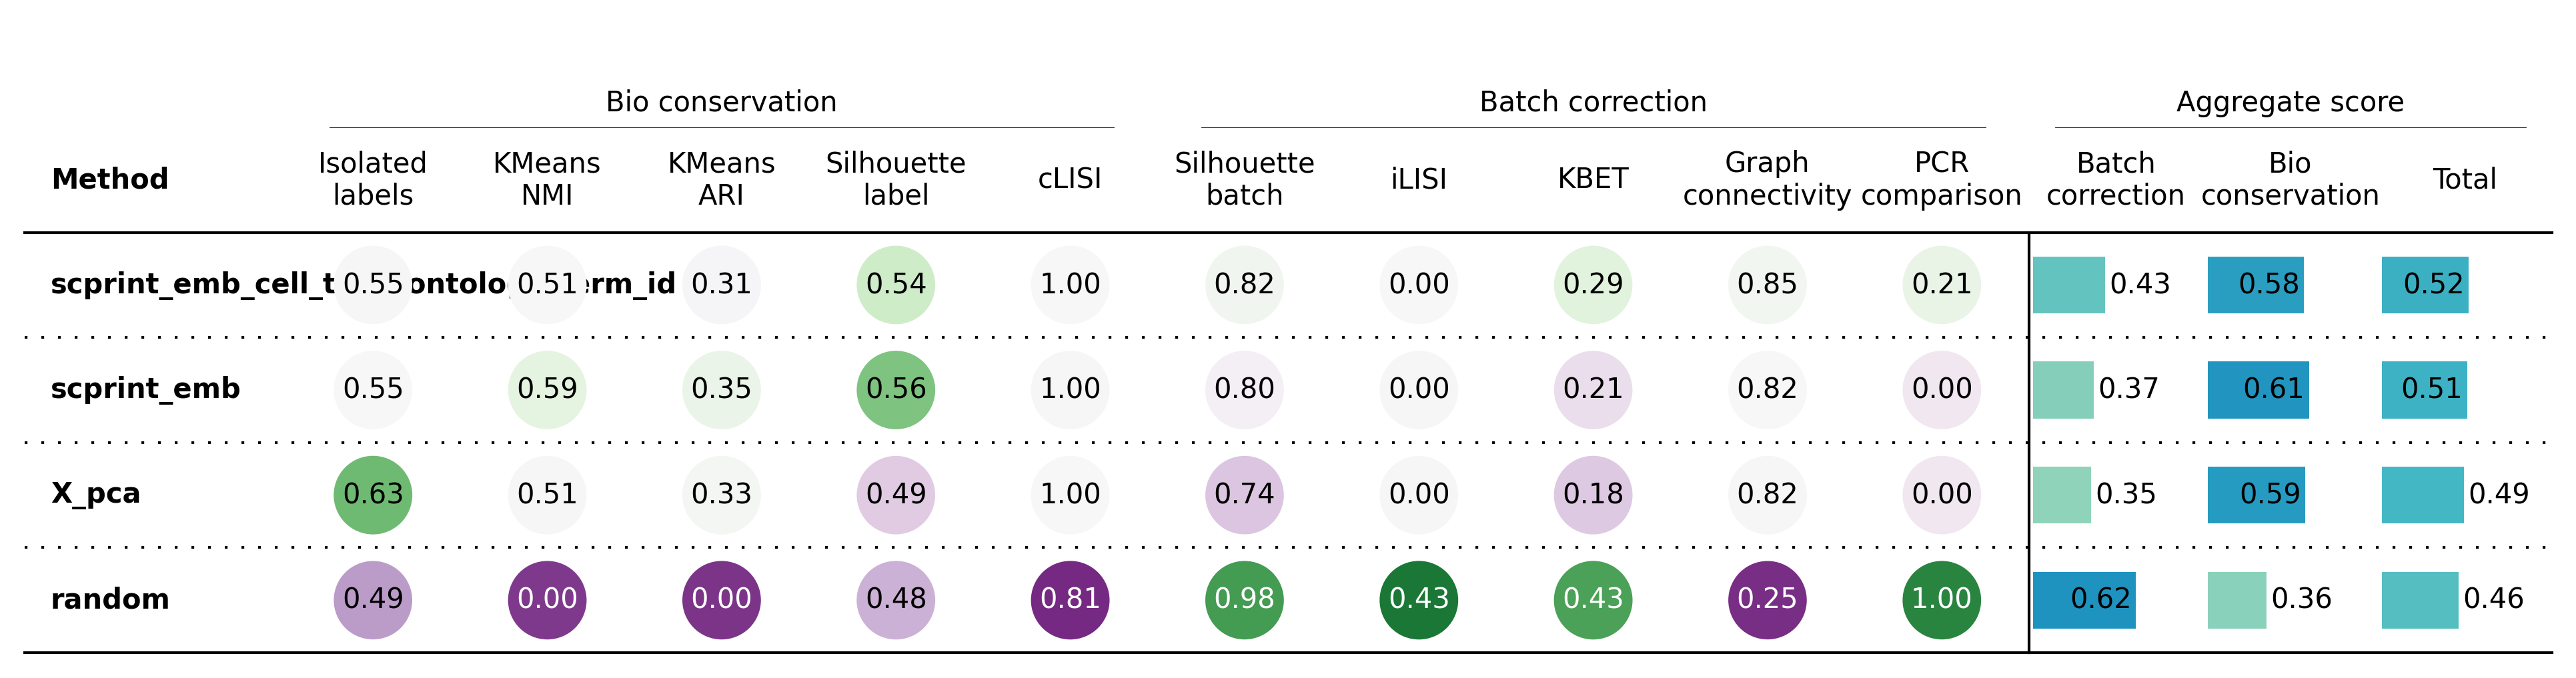

In [87]:
# cell_type embedding latest
bm.plot_results_table(min_max_scale=False)